# Graph Theory Foundations — Collusion Detection as Network Science

**Purpose:** This is a learning notebook, not a dashboard.  
Each section explains one mathematical concept, shows it on a toy example, then applies it to real data.

---

## Why Graph Theory?

Graph theory is a **formal branch of mathematics** originating in 1736 when Leonhard Euler solved the Königsberg bridge problem.  
It is the mathematical language of **relationships between things**.

Today it is the backbone of:
- Fraud detection (banking, insurance, telecom, crypto)
- Epidemiology (contact tracing)
- Cybersecurity (attack graph analysis)
- Intelligence (link analysis)
- Social network analysis

You are not inventing something speculative.  
You are applying an established mathematical framework to poker player interactions.

---

### The Three-Part Model

| Real World | Graph Theory Term | In This Project |
|---|---|---|
| A player | **Node** (vertex) $v \in V$ | `player_name` |
| Two players interacting | **Edge** $e \in E$ | hands played together |
| Chip transfer amount | **Edge weight** $w(e)$ | BB won/lost per pair |
| Who transfers to whom | **Directed edge** $(u \to v)$ | net chip direction |

The formal object we are building:

$$G = (V, E, w)$$

A **weighted directed graph** — textbook graph theory, nothing more.

In [1]:

# ── Section 1: Imports ────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import networkx as nx
import networkx.algorithms.community as nx_comm

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "monospace",
})

ROOT = Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()

print(f"NetworkX  : {nx.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Pandas    : {pd.__version__}")
print("All imports OK — no DB connection required.")


NetworkX  : 3.6.1
NumPy     : 2.4.2
Pandas    : 3.0.1
All imports OK — no DB connection required.


---
## Part 1 — What Does a Graph Actually Look Like?

Before touching real data: build a graph by hand.

A graph $G = (V, E)$ is simply a set of **nodes** and a set of **edges**.

```
V = {A, B, C, D, E}          # 5 players
E = {(A,B), (A,C), (B,C), (D,E)}  # who played who
```

We ask three questions immediately:
1. **Connectivity** — is the graph connected? Are there isolated subgroups?
2. **Degree** — how many edges does each node have? ($\deg(v)$)
3. **Density** — how full is the graph compared to the maximum possible edges?

$$\text{density} = \frac{|E|}{\binom{|V|}{2}} = \frac{|E|}{\frac{|V|(|V|-1)}{2}}$$

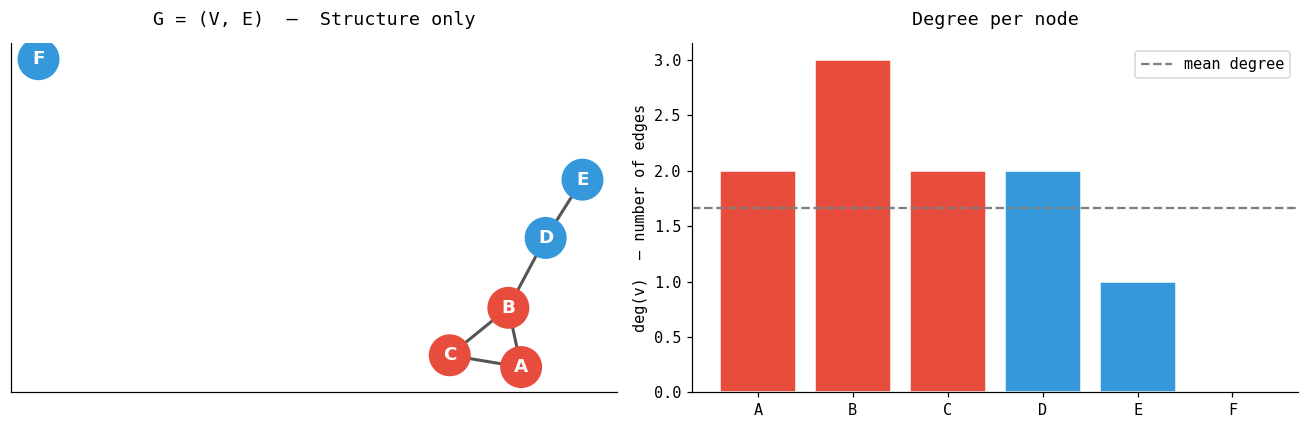

|V| = 6  nodes
|E| = 5  edges
density = 5 / 15 = 0.333

Cluster subgraph density:
  |V_sub|=3, |E_sub|=3, density=1.000  (max possible = 1.0)


In [2]:
# ── Toy undirected graph — structure at its most basic ───────────────────────
G_toy = nx.Graph()

# Two groups: a tight cluster (colluders) and a loose fringe
G_toy.add_nodes_from(["A", "B", "C"], group="cluster")   # dense internal group
G_toy.add_nodes_from(["D", "E", "F"], group="fringe")    # loose outside group

G_toy.add_edges_from([
    ("A", "B"), ("A", "C"), ("B", "C"),   # cluster: fully connected (K₃)
    ("D", "E"),                            # fringe: sparse
    ("B", "D"),                            # one bridge between groups
])

colors = ["#e74c3c" if G_toy.nodes[n]["group"] == "cluster" else "#3498db"
          for n in G_toy.nodes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pos = nx.spring_layout(G_toy, seed=42)

# Left: the graph itself
nx.draw_networkx(G_toy, pos=pos, ax=axes[0], node_color=colors,
                 node_size=700, font_color="white", font_weight="bold",
                 edge_color="#555", width=2)
axes[0].set_title("G = (V, E)  —  Structure only", pad=12)

# Right: degree bar chart
degrees = dict(G_toy.degree())
node_colors_bar = [
    "#e74c3c" if G_toy.nodes[n]["group"] == "cluster" else "#3498db"
    for n in degrees
]
axes[1].bar(degrees.keys(), degrees.values(), color=node_colors_bar, edgecolor="white")
axes[1].set_ylabel("deg(v)  — number of edges")
axes[1].set_title("Degree per node", pad=12)
axes[1].axhline(np.mean(list(degrees.values())), color="gray", ls="--", label="mean degree")
axes[1].legend()

plt.tight_layout()
plt.show()

n, m = G_toy.number_of_nodes(), G_toy.number_of_edges()
density = nx.density(G_toy)
print(f"|V| = {n}  nodes")
print(f"|E| = {m}  edges")
print(f"density = {m} / {n*(n-1)//2} = {density:.3f}")
print()
print("Cluster subgraph density:")
cluster_nodes = [n for n, d in G_toy.nodes(data=True) if d["group"] == "cluster"]
sub = G_toy.subgraph(cluster_nodes)
print(f"  |V_sub|={sub.number_of_nodes()}, |E_sub|={sub.number_of_edges()}, "
      f"density={nx.density(sub):.3f}  (max possible = 1.0)")

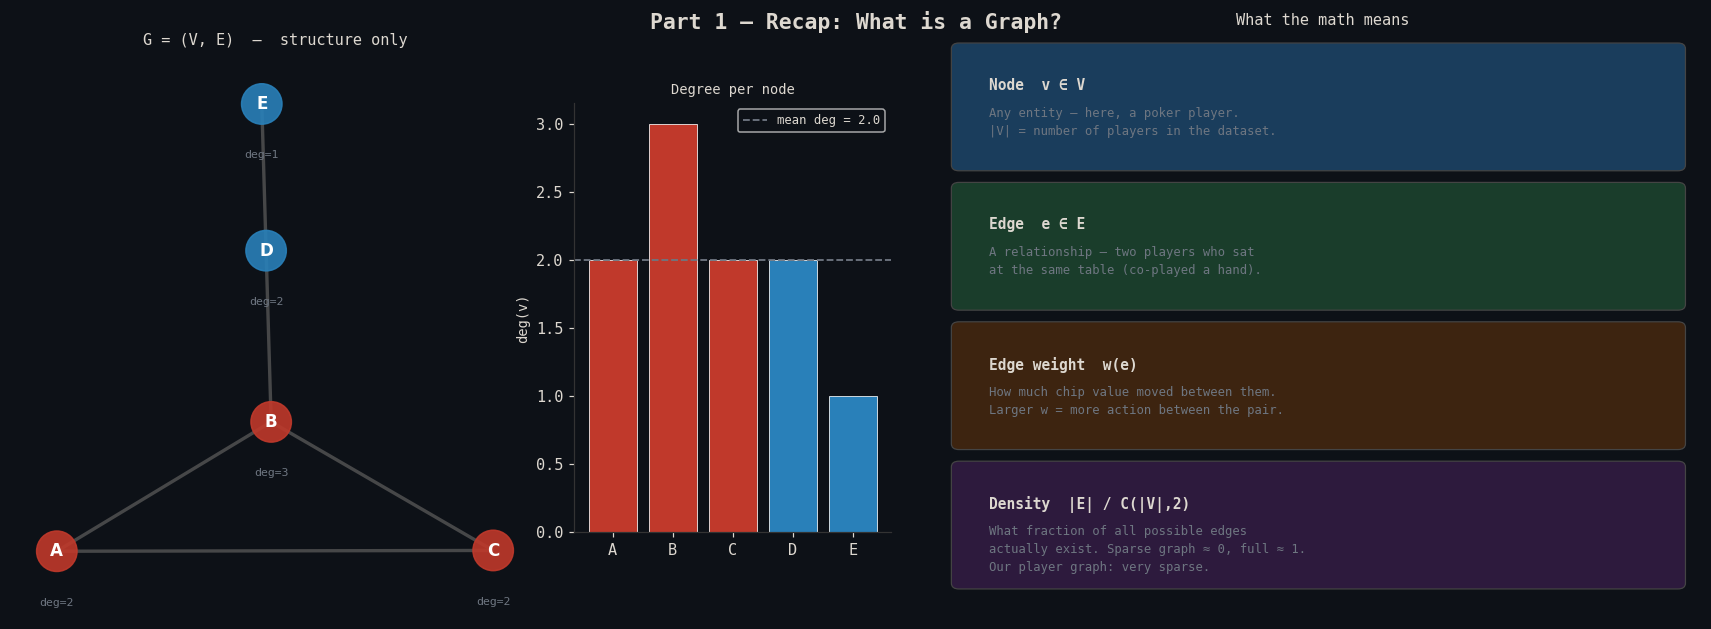

Part 1 recap: G = (V, E)  |  node = player  |  edge = co-play  |  weight = bb transferred  |  density = sparsity measure


In [3]:

# ── PART 1 RECAP ──────────────────────────────────────────────────────────────
# A self-contained summary diagram. No analysis — just the concept crystallised.

import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import networkx as nx

BG = "#0d1117"; FELT = "#1a3d2b"
CRED = "#c0392b"; CBLUE = "#2980b9"; WHITE = "#ddd8d0"; DIM = "#6e7681"

fig = plt.figure(figsize=(16, 6), facecolor=BG)
fig.text(0.5, 0.97, "Part 1 — Recap: What is a Graph?",
         ha="center", va="top", fontsize=14, fontweight="bold",
         color=WHITE, fontfamily="monospace")

# ── Panel A: a tiny graph with labelled parts ──────────────────────────────────
ax1 = fig.add_axes([0.02, 0.08, 0.30, 0.82])
ax1.set_facecolor(BG)
ax1.set_title("G = (V, E)  —  structure only", color=WHITE, fontsize=10, pad=8)

G5 = nx.Graph()
G5.add_nodes_from(["A","B","C","D","E"])
G5.add_edges_from([("A","B"),("A","C"),("B","C"),("B","D"),("D","E")])
pos5 = nx.spring_layout(G5, seed=11)
cols5 = [CRED if n in ("A","B","C") else CBLUE for n in G5.nodes]
nx.draw_networkx_nodes(G5, pos5, ax=ax1, node_color=cols5, node_size=700, alpha=0.9)
nx.draw_networkx_labels(G5, pos5, ax=ax1, font_color="white", font_weight="bold", font_size=11)
nx.draw_networkx_edges(G5, pos5, ax=ax1, edge_color="#555", width=2.2, alpha=0.8)
# degree annotations
for n, (x, y) in pos5.items():
    d = G5.degree(n)
    ax1.text(x, y - 0.17, f"deg={d}", ha="center", va="top",
             fontsize=7.5, color=DIM, fontfamily="monospace")
ax1.axis("off")

# ── Panel B: degree bar ────────────────────────────────────────────────────────
ax2 = fig.add_axes([0.34, 0.18, 0.18, 0.65])
ax2.set_facecolor(BG)
degs = dict(G5.degree())
bar_cols = [CRED if n in ("A","B","C") else CBLUE for n in degs]
ax2.bar(degs.keys(), degs.values(), color=bar_cols, edgecolor="white", linewidth=0.5)
ax2.axhline(np.mean(list(degs.values())), color=DIM, ls="--", lw=1.2,
            label=f"mean deg = {np.mean(list(degs.values())):.1f}")
ax2.set_ylabel("deg(v)", color=WHITE, fontsize=9)
ax2.set_title("Degree per node", color=WHITE, fontsize=9, pad=6)
ax2.tick_params(colors=WHITE); ax2.legend(fontsize=8, labelcolor=WHITE, facecolor=BG)
for sp in ax2.spines.values(): sp.set_color("#333")

# ── Panel C: 3 key formulas & takeaways ───────────────────────────────────────
ax3 = fig.add_axes([0.55, 0.05, 0.43, 0.88])
ax3.set_facecolor(BG); ax3.axis("off")
ax3.set_title("What the math means", color=WHITE, fontsize=10, pad=8)

cards = [
    ("Node  v ∈ V", "Any entity — here, a poker player.\n|V| = number of players in the dataset.",
     "#1a3d5c"),
    ("Edge  e ∈ E", "A relationship — two players who sat\nat the same table (co-played a hand).",
     "#1a3d2b"),
    ("Edge weight  w(e)", "How much chip value moved between them.\nLarger w = more action between the pair.",
     "#3d2410"),
    ("Density  |E| / C(|V|,2)", "What fraction of all possible edges\nactually exist. Sparse graph ≈ 0, full ≈ 1.\nOur player graph: very sparse.",
     "#2d1a3d"),
]
for i, (title, body, bg) in enumerate(cards):
    y0 = 0.78 - i * 0.24
    rect = mpatches.FancyBboxPatch((0.02, y0), 0.95, 0.20,
                                   boxstyle="round,pad=0.01",
                                   facecolor=bg, edgecolor="#444", linewidth=0.8)
    ax3.add_patch(rect)
    ax3.text(0.06, y0 + 0.15, title, fontsize=9.5, fontweight="bold",
             color=WHITE, fontfamily="monospace", va="top")
    ax3.text(0.06, y0 + 0.10, body, fontsize=8.0, color=DIM,
             va="top", linespacing=1.5)

ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
plt.show()
print("Part 1 recap: G = (V, E)  |  node = player  |  edge = co-play  |  weight = bb transferred  |  density = sparsity measure")



---
## Part 2 — Adding Direction and Weight: The Poker Table

Undirected edges tell us *who sat at the same table*.  
**Directed weighted edges** tell us *how much value moved, and in which direction*.

$$G = (V, E, w) \quad \text{where} \quad w : E \to \mathbb{R}^+$$

Each directed edge $(u \to v)$ has weight $w_{uv}$ = big blinds that flowed from $u$ to $v$ across all shared hands.

**This is not a metaphor. It is the textbook definition of a weighted directed graph.**

---

### What we're looking for — and why it is structurally visible

In **normal poker**, a losing session distributes chips across the whole table.  
You lose 200 bb tonight: some of that goes to the player on your left, some to the player across, some to the big stack. The flow is diffuse and roughly balanced over a large sample.

In **chip dumping**, the same 200 bb resolves to *one specific player* — hand after hand, session after session.

Define the **flow imbalance** for a pair $(i, j)$:

$$\text{asym}_{ij} = \frac{w_{i \to j} - w_{j \to i}}{w_{i \to j} + w_{j \to i}}$$

| Value | Meaning |
|---|---|
| $\approx 0$ | Balanced — normal high-variance play |
| $> 0.5$ | One player consistently wins from the other |
| $> 0.85$ + high volume | **Structurally anomalous** — flagged |

The cell below places our toy players around a **poker table oval** so you can see the direction of chip flow geometrically. Red arrows are the dump signal; gray arrows are symmetric play that a graph-theory filter ignores.


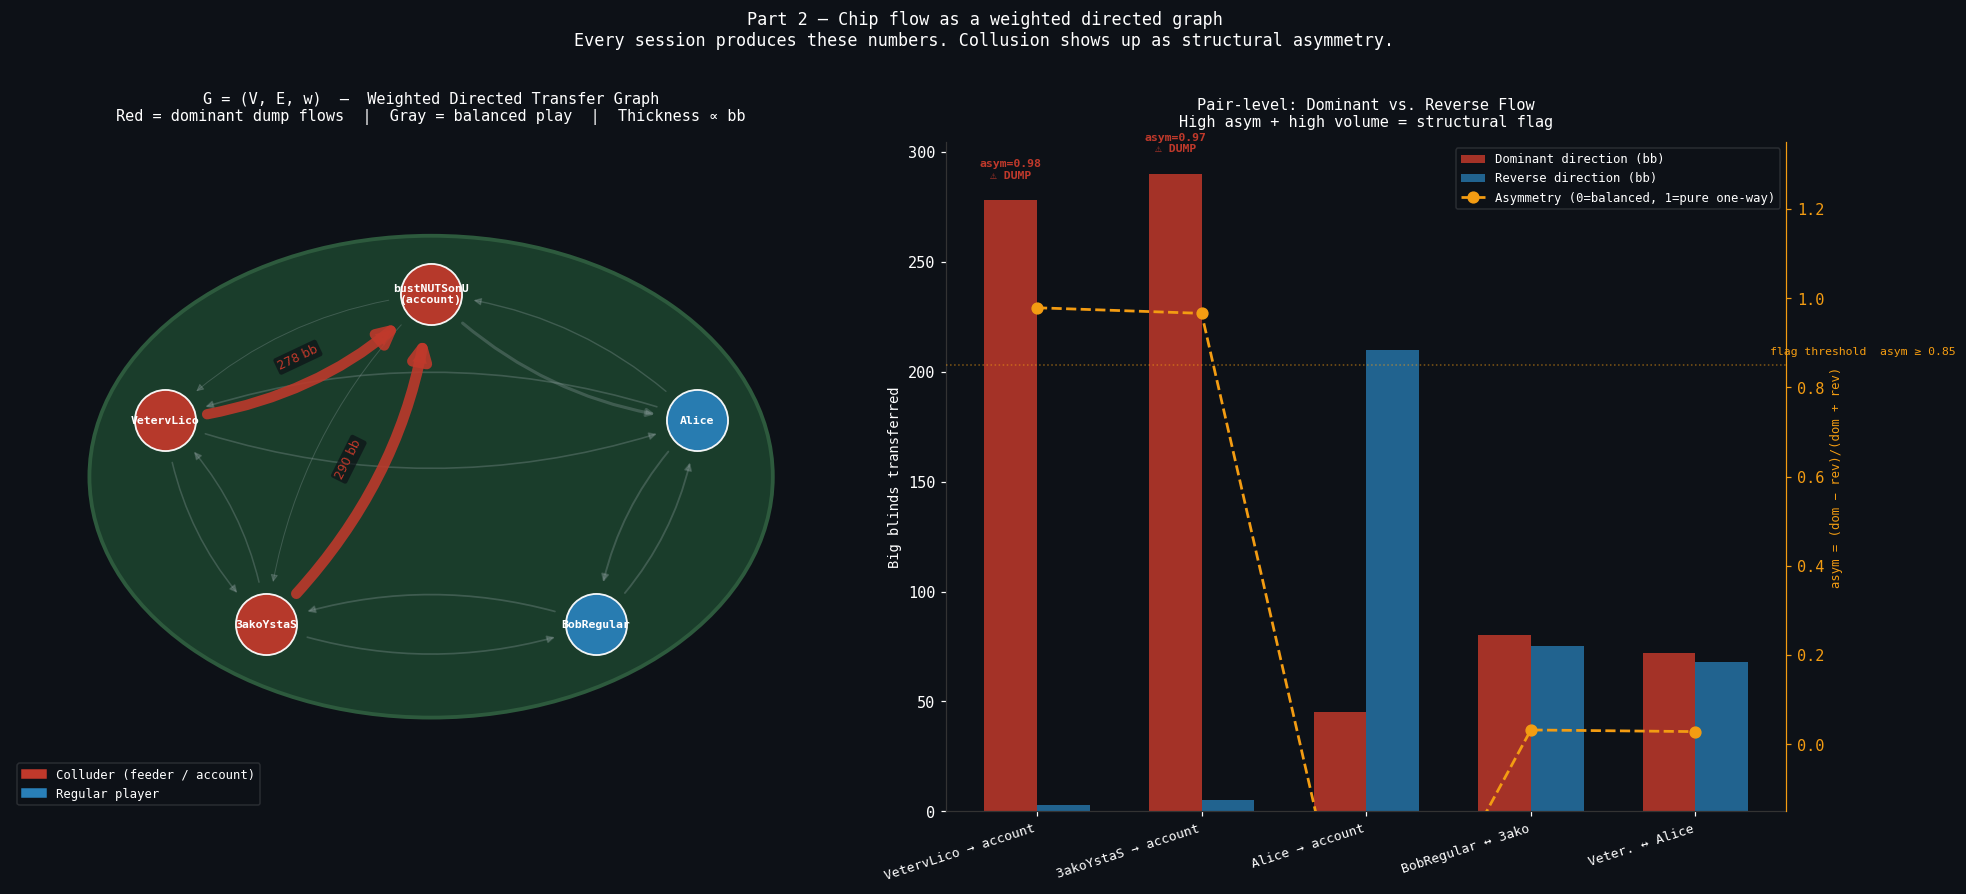


                      player   in_flow   out_flow    net_bb
                  VetervLico       133        408      -275
                   3akoYstaS       147        423      -276
       bustNUTSonU (account)       613        218      +395
                       Alice       366        212      +154
                  BobRegular       170        168        +2


In [4]:

# ── Part 2: Poker-table chip flow — weighted directed graph ───────────────────
#
# Scenario (made up, illustrative):
#   VetervLico and 3akoYstaS are feeding chips to bustNUTSonU (the "account").
#   The two regular players, Alice and BobRegular, run roughly even against everyone.
#
# We place players around a poker table oval so the direction of arrows
# immediately shows who is draining chips to whom.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ── Graph definition ───────────────────────────────────────────────────────────
DG = nx.DiGraph()

ACCOUNT = "bustNUTSonU\n(account)"
COLLUDERS = ["VetervLico", "3akoYstaS", ACCOUNT]
REGULARS  = ["Alice", "BobRegular"]
DG.add_nodes_from(COLLUDERS, group="collusion")
DG.add_nodes_from(REGULARS,  group="regular")

edges = [
    # ── dump flows: massive one-way ──────────────────────────────────────────
    ("VetervLico",  ACCOUNT, 278),
    (ACCOUNT,       "VetervLico",  3),    # tiny reverse
    ("3akoYstaS",   ACCOUNT, 290),
    (ACCOUNT,       "3akoYstaS",   5),    # tiny reverse
    # ── within-ring (symmetric → not a flag on its own) ─────────────────────
    ("VetervLico",  "3akoYstaS",  62),
    ("3akoYstaS",   "VetervLico", 58),
    # ── regular players: balanced ────────────────────────────────────────────
    ("Alice",       "BobRegular",  95),
    ("BobRegular",  "Alice",       88),
    ("Alice",       "VetervLico",  72),
    ("VetervLico",  "Alice",       68),
    ("BobRegular",  "3akoYstaS",   80),
    ("3akoYstaS",   "BobRegular",  75),
    # ── account wins legitimately from regulars too ──────────────────────────
    ("Alice",       ACCOUNT, 45),
    (ACCOUNT,       "Alice",      210),
]
for u, v, w in edges:
    DG.add_edge(u, v, weight=w)

# ── Poker-table oval positions ─────────────────────────────────────────────────
angles = {
    ACCOUNT:        np.pi / 2,
    "VetervLico":   np.pi / 2 + 2 * np.pi / 5,
    "3akoYstaS":    np.pi / 2 + 4 * np.pi / 5,
    "Alice":        np.pi / 2 - 2 * np.pi / 5,
    "BobRegular":   np.pi / 2 - 4 * np.pi / 5,
}
rx, ry = 3.0, 1.8
pos = {n: (rx * np.cos(a), ry * np.sin(a)) for n, a in angles.items()}

# ── Colours ────────────────────────────────────────────────────────────────────
CRED  = "#c0392b"
CBLUE = "#2980b9"
CGRAY = "#95a5a6"
BG    = "#0d1117"
FELT  = "#1a3d2b"

node_colors = [CRED if DG.nodes[n]["group"] == "collusion" else CBLUE
               for n in DG.nodes]
max_w = max(d["weight"] for _, _, d in DG.edges(data=True))

def is_dump(u, v, w):
    rev  = DG[v][u]["weight"] if DG.has_edge(v, u) else 0
    asym = (w - rev) / (w + rev + 1e-6)
    return asym > 0.85 and w > 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG)

# ─────────────────────────────────────────────────────────────────────────────
# LEFT: full poker table
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)

# felt oval
ell = mpatches.Ellipse((0, 0), 2 * rx * 1.22, 2 * ry * 1.32,
                        facecolor=FELT, edgecolor="#2d5a3d", linewidth=2.5, zorder=0)
ax.add_patch(ell)

# draw gray (normal) edges first
for u, v, d in DG.edges(data=True):
    w = d["weight"]
    if not is_dump(u, v, w):
        nx.draw_networkx_edges(DG, pos, edgelist=[(u, v)], ax=ax,
                               width=0.6 + 2.0 * w / max_w,
                               edge_color=CGRAY, alpha=0.30,
                               arrows=True, arrowsize=10,
                               connectionstyle="arc3,rad=0.18",
                               min_source_margin=28, min_target_margin=28)

# draw red (dump) edges on top
dump_label_map = {}
for u, v, d in DG.edges(data=True):
    w = d["weight"]
    if is_dump(u, v, w):
        nx.draw_networkx_edges(DG, pos, edgelist=[(u, v)], ax=ax,
                               width=1.0 + 6.0 * w / max_w,
                               edge_color=CRED, alpha=0.88,
                               arrows=True, arrowsize=24,
                               connectionstyle="arc3,rad=0.18",
                               min_source_margin=28, min_target_margin=28)
        dump_label_map[(u, v)] = f"{w} bb"

# nodes (drawn manually to control layering)
for node, (x, y) in pos.items():
    col = CRED if DG.nodes[node]["group"] == "collusion" else CBLUE
    ax.scatter(x, y, s=1600, color=col, alpha=0.95, edgecolors="white",
               linewidths=1.2, zorder=5)
    label = node.replace("\n", "\n")  # keep as-is
    ax.text(x, y, label, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white", zorder=6,
            multialignment="center")

# dump flow labels
nx.draw_networkx_edge_labels(DG, pos, dump_label_map, ax=ax,
                             font_size=8, font_color=CRED,
                             bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec="none", alpha=0.7))

ax.set_xlim(-4.5, 4.5); ax.set_ylim(-3.3, 3.3)
ax.axis("off")
ax.set_title("G = (V, E, w)  —  Weighted Directed Transfer Graph\n"
             "Red = dominant dump flows  |  Gray = balanced play  |  Thickness ∝ bb",
             color="white", pad=14, fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color=CRED,  label="Colluder (feeder / account)"),
    mpatches.Patch(color=CBLUE, label="Regular player"),
], loc="lower left", framealpha=0.15, labelcolor="white", facecolor=BG, fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# RIGHT: Dominant vs Reverse bb + asymmetry per pair
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)

pairs = [
    ("VetervLico → account", 278, 3),
    ("3akoYstaS → account",  290, 5),
    ("Alice → account",       45, 210),
    ("BobRegular ↔ 3ako",    80,  75),
    ("Veter. ↔ Alice",        72,  68),
]
plabels  = [p[0] for p in pairs]
dominant = [p[1] for p in pairs]
reverse  = [p[2] for p in pairs]
asym     = [(d - r) / (d + r + 1e-6) for d, r in zip(dominant, reverse)]

x  = np.arange(len(plabels))
bw = 0.32

bars1 = ax2.bar(x - bw/2, dominant, bw, label="Dominant direction (bb)", color=CRED,  alpha=0.85)
bars2 = ax2.bar(x + bw/2, reverse,  bw, label="Reverse direction (bb)",  color=CBLUE, alpha=0.75)

ax2b = ax2.twinx()
ax2b.plot(x, asym, "o--", color="#f39c12", lw=1.8, ms=7,
          label="Asymmetry (0=balanced, 1=pure one-way)")
ax2b.axhline(0.85, color="#f39c12", lw=1, ls=":", alpha=0.5)
ax2b.text(len(pairs) - 0.55, 0.87, "flag threshold  asym ≥ 0.85",
          color="#f39c12", fontsize=7.5, va="bottom")
ax2b.set_ylim(-0.15, 1.35)
ax2b.set_ylabel("asym = (dom − rev)/(dom + rev)", color="#f39c12", fontsize=8)
ax2b.tick_params(colors="#f39c12")
for sp in ["right", "top", "left", "bottom"]:
    ax2b.spines[sp].set_visible(False)
ax2b.spines["right"].set_visible(True)
ax2b.spines["right"].set_color("#f39c12")

ax2.set_xticks(x)
ax2.set_xticklabels(plabels, rotation=18, ha="right", fontsize=8.5, color="white")
ax2.tick_params(colors="white")
for sp in ax2.spines.values():
    sp.set_color("#333")
ax2.set_ylabel("Big blinds transferred", color="white", fontsize=9)
ax2.set_title("Pair-level: Dominant vs. Reverse Flow\n"
              "High asym + high volume = structural flag", color="white", fontsize=10, pad=10)

# annotate dump pairs
for i, (bar, a, dom) in enumerate(zip(bars1, asym, dominant)):
    if a > 0.85:
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 dom + 9, f"asym={a:.2f}\n⚠ DUMP",
                 ha="center", va="bottom", fontsize=7.5,
                 color=CRED, fontweight="bold")

lines1, lbs1 = ax2.get_legend_handles_labels()
lines2, lbs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lbs1 + lbs2, loc="upper right",
           framealpha=0.15, labelcolor="white", facecolor=BG, fontsize=8)

plt.suptitle(
    "Part 2 — Chip flow as a weighted directed graph\n"
    "Every session produces these numbers. Collusion shows up as structural asymmetry.",
    color="white", fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

# ── Node summary ───────────────────────────────────────────────────────────────
print(f"\n{'player':>28}  {'in_flow':>8}  {'out_flow':>9}  {'net_bb':>8}")
for node in DG.nodes:
    in_f  = sum(DG[u][node]["weight"] for u in DG.predecessors(node))
    out_f = sum(DG[node][v]["weight"] for v in DG.successors(node))
    print(f"{node.replace(chr(10),' '):>28}  {in_f:>8.0f}  {out_f:>9.0f}  {in_f - out_f:>+8.0f}")


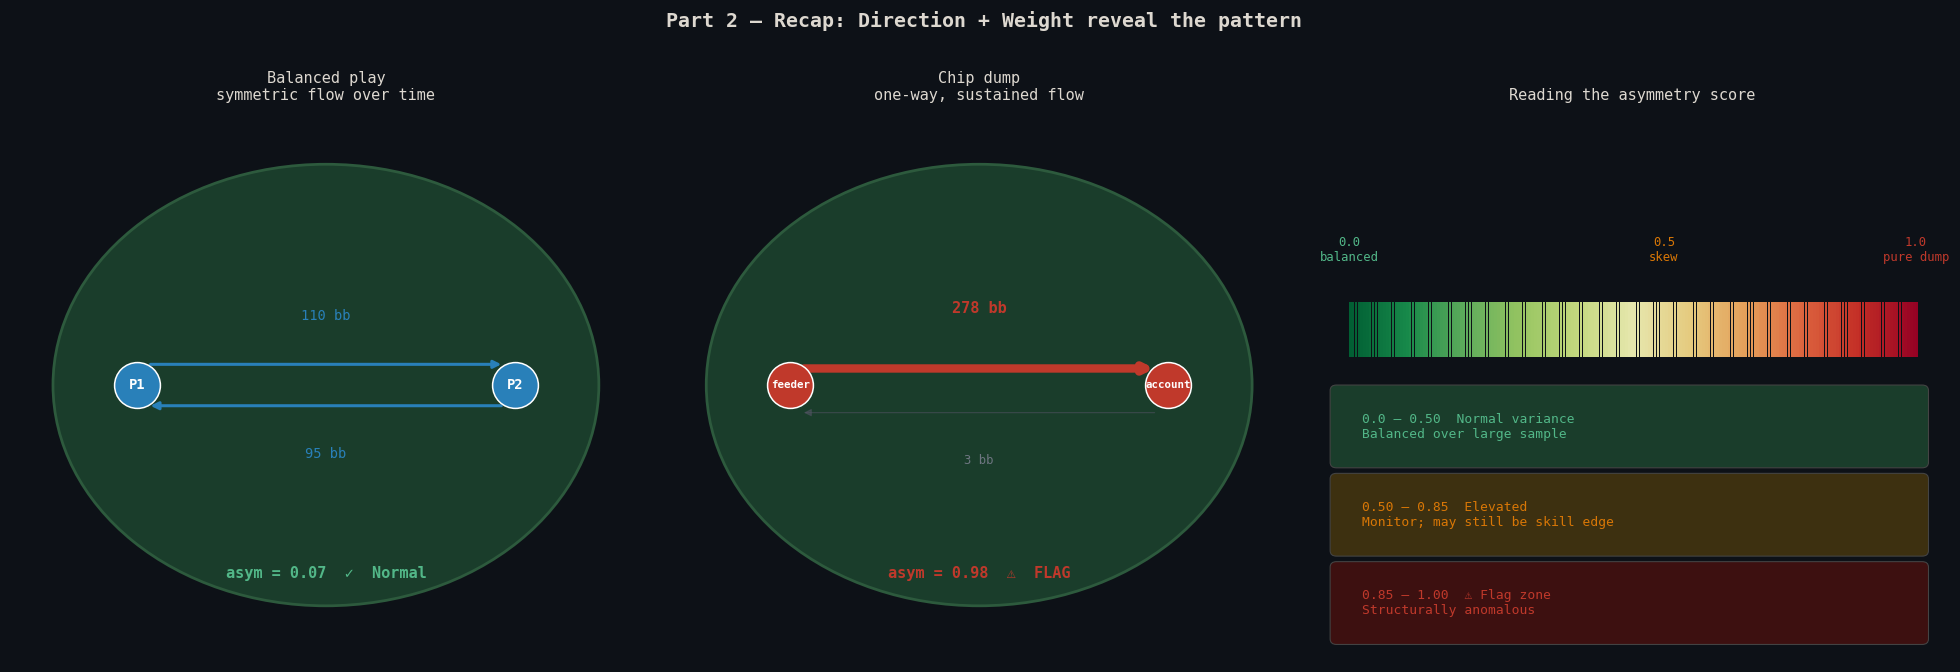

Part 2 recap: asym(i→j) = (w_ij - w_ji) / (w_ij + w_ji)  |  0 = normal  |  ~1 = structural anomaly


In [5]:

# ── PART 2 RECAP ──────────────────────────────────────────────────────────────
# Side-by-side: normal play vs chip dump — what the arrows look like.

import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import networkx as nx

BG = "#0d1117"; FELT = "#1a3d2b"; WHITE = "#ddd8d0"; DIM = "#6e7681"
CRED = "#c0392b"; CBLUE = "#2980b9"; CGRAY = "#555566"; CAMBER = "#d97706"

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)
fig.suptitle("Part 2 — Recap: Direction + Weight reveal the pattern",
             fontsize=13, fontweight="bold", color=WHITE, fontfamily="monospace", y=1.01)

# ─────────────────────────────────────────────────────────────────────────────
# Panel A: Normal play — balanced, bidirectional
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(BG)
ax.add_patch(mpatches.Ellipse((0,0), 5.2, 3.2, facecolor=FELT, edgecolor="#2d5a3d", lw=1.8, zorder=0))

# two players with balanced arrows
ax.annotate("", xy=( 1.7, 0.15), xytext=(-1.7,  0.15),
            arrowprops=dict(arrowstyle="-|>", color=CBLUE, lw=2.0))
ax.annotate("", xy=(-1.7,-0.15), xytext=( 1.7, -0.15),
            arrowprops=dict(arrowstyle="-|>", color=CBLUE, lw=2.0))
ax.scatter([-1.8, 1.8], [0, 0], s=900, color=CBLUE, edgecolors="white", lw=1, zorder=5)
ax.text(-1.8, 0, "P1", ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=6)
ax.text( 1.8, 0, "P2", ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=6)
ax.text(0,  0.45, "110 bb", ha="center", va="bottom", color=CBLUE, fontsize=9, fontfamily="monospace")
ax.text(0, -0.45, "95 bb",  ha="center", va="top",    color=CBLUE, fontsize=9, fontfamily="monospace")
ax.text(0, -1.4, "asym = 0.07  ✓  Normal", ha="center", color="#52b788", fontsize=10, fontweight="bold")
ax.set_xlim(-3, 3); ax.set_ylim(-2, 2); ax.axis("off")
ax.set_title("Balanced play\nsymmetric flow over time", color=WHITE, fontsize=10, pad=6)

# ─────────────────────────────────────────────────────────────────────────────
# Panel B: Chip dump — one massive arrow, tiny reverse
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor(BG)
ax.add_patch(mpatches.Ellipse((0,0), 5.2, 3.2, facecolor=FELT, edgecolor="#2d5a3d", lw=1.8, zorder=0))

# thick dump arrow
ax.annotate("", xy=(1.7, 0.12), xytext=(-1.7, 0.12),
            arrowprops=dict(arrowstyle="-|>", color=CRED, lw=5.5))
# tiny reverse
ax.annotate("", xy=(-1.7, -0.2), xytext=(1.7, -0.2),
            arrowprops=dict(arrowstyle="-|>", color=CGRAY, lw=0.8, alpha=0.5))
ax.scatter([-1.8], [0], s=900, color=CRED,  edgecolors="white", lw=1, zorder=5)
ax.scatter([ 1.8], [0], s=900, color=CRED,  edgecolors="white", lw=1, zorder=5)
ax.text(-1.8, 0, "feeder", ha="center", va="center", color="white", fontsize=7, fontweight="bold", zorder=6)
ax.text( 1.8, 0, "account", ha="center", va="center", color="white", fontsize=7, fontweight="bold", zorder=6)
ax.text(0,  0.50, "278 bb", ha="center", va="bottom", color=CRED,  fontsize=10, fontweight="bold", fontfamily="monospace")
ax.text(0, -0.50, "3 bb",   ha="center", va="top",    color=DIM,   fontsize=8, fontfamily="monospace")
ax.text(0, -1.4, "asym = 0.98  ⚠  FLAG", ha="center", color=CRED, fontsize=10, fontweight="bold")
ax.set_xlim(-3, 3); ax.set_ylim(-2, 2); ax.axis("off")
ax.set_title("Chip dump\none-way, sustained flow", color=WHITE, fontsize=10, pad=6)

# ─────────────────────────────────────────────────────────────────────────────
# Panel C: asym scale + what each zone means
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[2]; ax.set_facecolor(BG); ax.axis("off")
ax.set_title("Reading the asymmetry score", color=WHITE, fontsize=10, pad=6)

# gradient bar
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn_r
norm = mcolors.Normalize(0, 1)
for xi in np.linspace(0, 1, 200):
    ax.barh(0.6, 0.004, left=0.05 + xi * 0.90, height=0.10,
            color=cmap(norm(xi)), alpha=0.9)
ax.text(0.05, 0.72, "0.0\nbalanced", ha="center", va="bottom", fontsize=8, color="#52b788")
ax.text(0.55, 0.72, "0.5\nskew",     ha="center", va="bottom", fontsize=8, color=CAMBER)
ax.text(0.95, 0.72, "1.0\npure dump",ha="center", va="bottom", fontsize=8, color=CRED)

zones = [
    (0.0, 0.5,  "#1a3d2b", "#52b788", "0.0 – 0.50  Normal variance\nBalanced over large sample"),
    (0.5, 0.85, "#3d3010", CAMBER,    "0.50 – 0.85  Elevated\nMonitor; may still be skill edge"),
    (0.85, 1.0, "#3d1010", CRED,      "0.85 – 1.00  ⚠ Flag zone\nStructurally anomalous"),
]
for i, (x0, x1, bg, tc, label) in enumerate(zones):
    y = 0.36 - i * 0.16
    rect = mpatches.FancyBboxPatch((0.03, y), 0.93, 0.13,
                                   boxstyle="round,pad=0.01",
                                   facecolor=bg, edgecolor="#444", lw=0.7)
    ax.add_patch(rect)
    ax.text(0.07, y + 0.065, label, va="center", fontsize=8.5,
            color=tc, fontfamily="monospace")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
print("Part 2 recap: asym(i→j) = (w_ij - w_ji) / (w_ij + w_ji)  |  0 = normal  |  ~1 = structural anomaly")



---
## Part 3 — Scaling Up: A Full Player Network

The toy graph had 5 players. Now we scale to a realistic player population.

We construct $G = (V, E, w)$ from a simulated dataset of **~80 players** across several cohorts — mimicking what a real cash-game hand-history dataset produces after the transfer graph formula is applied to every hand.

Each row in the edge list is a directed pair: `donor → recipient` with:
- `total_transfer_bb` — BB flowing in the dominant direction  
- `reverse_transfer_bb` — BB flowing back  
- `asym` — directional imbalance score  
- `hands_together` — co-play volume gate

Most players interact normally. A small cluster of accounts shows structurally anomalous flow. The graph makes this difference visible.


In [6]:

# ── Part 3: Simulate a realistic multi-player transfer graph ──────────────────
# No database needed — this constructs a representative edge list
# matching the structure a real NLHE cash-game dataset would produce
# after applying the proportional transfer formula to every hand.
#
# Structure:
#   Community A (20 players) — regular cohort, high internal volume
#   Community B (18 players) — regular cohort
#   Community C (15 players) — mixed, moderate play
#   Collusion ring (6 accounts): 1 account + 5 feeders
#   Periphery  (21 players)  — occasional visitors, sparse edges

import numpy as np, pandas as pd, networkx as nx
import networkx.algorithms.community as nx_comm

rng = np.random.default_rng(42)

def _cohort(prefix, n):
    return [f"{prefix}{i:02d}" for i in range(1, n + 1)]

cohort_a = _cohort("PlayerA", 20)
cohort_b = _cohort("PlayerB", 18)
cohort_c = _cohort("PlayerC", 15)
periphery = _cohort("Visitor", 21)

ACCOUNT  = "bustNUTSonU"          # chip sink
FEEDERS  = ["VetervLico", "3akoYstaS", "Kakiss", "ScavannA", "Pokernooob"]

all_players = cohort_a + cohort_b + cohort_c + periphery + FEEDERS + [ACCOUNT]

rows = []

# ── Normal cohort edges (balanced, high volume) ────────────────────────────────
def add_cohort_edges(members, vol_range=(60, 320), hands_range=(60, 160)):
    for i, pa in enumerate(members):
        for pb in members[i+1:]:
            if rng.random() < 0.55:            # not every pair meets
                dom = float(rng.integers(*vol_range))
                rev = float(rng.integers(int(dom * 0.70), int(dom * 1.00)))
                ht  = int(rng.integers(*hands_range))
                asym = (dom - rev) / (dom + rev + 1e-6)
                # keep dominant direction
                if asym > 0:
                    rows.append(dict(donor=pa, recipient=pb,
                                     total_transfer_bb=dom, reverse_transfer_bb=rev,
                                     asym=abs(asym), hands_together=ht))
                else:
                    rows.append(dict(donor=pb, recipient=pa,
                                     total_transfer_bb=rev, reverse_transfer_bb=dom,
                                     asym=abs(asym), hands_together=ht))

add_cohort_edges(cohort_a, vol_range=(80, 350), hands_range=(65, 180))
add_cohort_edges(cohort_b, vol_range=(60, 280), hands_range=(55, 140))
add_cohort_edges(cohort_c, vol_range=(40, 200), hands_range=(50, 120))

# ── Cross-cohort edges (sparse, balanced) ─────────────────────────────────────
for _ in range(60):
    pa = rng.choice(cohort_a + cohort_b)
    pb = rng.choice(cohort_b + cohort_c)
    if pa != pb:
        dom = float(rng.integers(30, 150))
        rev = float(rng.integers(int(dom * 0.65), int(dom * 0.95)))
        ht  = int(rng.integers(50, 100))
        asym = abs(dom - rev) / (dom + rev + 1e-6)
        rows.append(dict(donor=pa, recipient=pb,
                         total_transfer_bb=dom, reverse_transfer_bb=rev,
                         asym=asym, hands_together=ht))

# ── Periphery (sparse, low volume) ────────────────────────────────────────────
for v in periphery:
    for _ in range(rng.integers(1, 4)):
        others = cohort_a + cohort_b + cohort_c
        other  = rng.choice(others)
        dom    = float(rng.integers(20, 100))
        rev    = float(rng.integers(int(dom * 0.60), int(dom * 0.98)))
        ht     = int(rng.integers(50, 80))
        rows.append(dict(donor=v, recipient=other,
                         total_transfer_bb=dom, reverse_transfer_bb=rev,
                         asym=abs(dom - rev) / (dom + rev + 1e-6),
                         hands_together=ht))

# ── Collusion ring: feeders dump to ACCOUNT ────────────────────────────────────
DUMP_AMOUNTS = {"VetervLico": 278, "3akoYstaS": 290, "Kakiss": 123, "ScavannA": 122, "Pokernooob": 109}
for feeder, dump_bb in DUMP_AMOUNTS.items():
    # dominant dump leg (asym ≈ 0.97)
    rows.append(dict(donor=feeder, recipient=ACCOUNT,
                     total_transfer_bb=float(dump_bb), reverse_transfer_bb=3.0,
                     asym=(dump_bb - 3) / (dump_bb + 3 + 1e-6),
                     hands_together=rng.integers(75, 120)))
    # feeders also play normally against cohort_a
    for other in rng.choice(cohort_a, 4, replace=False):
        dom = float(rng.integers(50, 200))
        rev = float(rng.integers(int(dom * 0.72), int(dom * 0.97)))
        ht  = int(rng.integers(55, 130))
        rows.append(dict(donor=feeder, recipient=other,
                         total_transfer_bb=dom, reverse_transfer_bb=rev,
                         asym=abs(dom - rev) / (dom + rev + 1e-6),
                         hands_together=ht))

df_edges = pd.DataFrame(rows)
df_edges["net_bb"] = df_edges["total_transfer_bb"] - df_edges["reverse_transfer_bb"]

# ── Build directed graph ─────────────────────────────────────────────────────
G_real = nx.DiGraph()
for _, row in df_edges.iterrows():
    G_real.add_edge(row["donor"], row["recipient"],
                    weight=row["total_transfer_bb"],
                    net_bb=row["net_bb"],
                    asym=row["asym"],
                    hands=row["hands_together"])

print(f"Simulated player transfer graph:")
print(f"  |V| = {G_real.number_of_nodes():,} nodes  (players)")
print(f"  |E| = {G_real.number_of_edges():,} directed edges  (dominant chip flows)")
print(f"  density = {nx.density(G_real):.4f}")
print(f"  weakly connected components: {nx.number_weakly_connected_components(G_real)}")
print()
print("Top 5 edges by transfer volume:")
for _, r in df_edges.nlargest(5, "total_transfer_bb").iterrows():
    print(f"  {r['donor']:20s} → {r['recipient']:20s}  "
          f"{r['total_transfer_bb']:7.1f} bb  asym={r['asym']:.3f}")


Simulated player transfer graph:
  |V| = 80 nodes  (players)
  |E| = 360 directed edges  (dominant chip flows)
  density = 0.0570
  weakly connected components: 1

Top 5 edges by transfer volume:
  PlayerA10            → PlayerA19               348.0 bb  asym=0.040
  PlayerA08            → PlayerA20               342.0 bb  asym=0.119
  PlayerA06            → PlayerA20               341.0 bb  asym=0.001
  PlayerA13            → PlayerA20               341.0 bb  asym=0.022
  PlayerA15            → PlayerA17               339.0 bb  asym=0.024


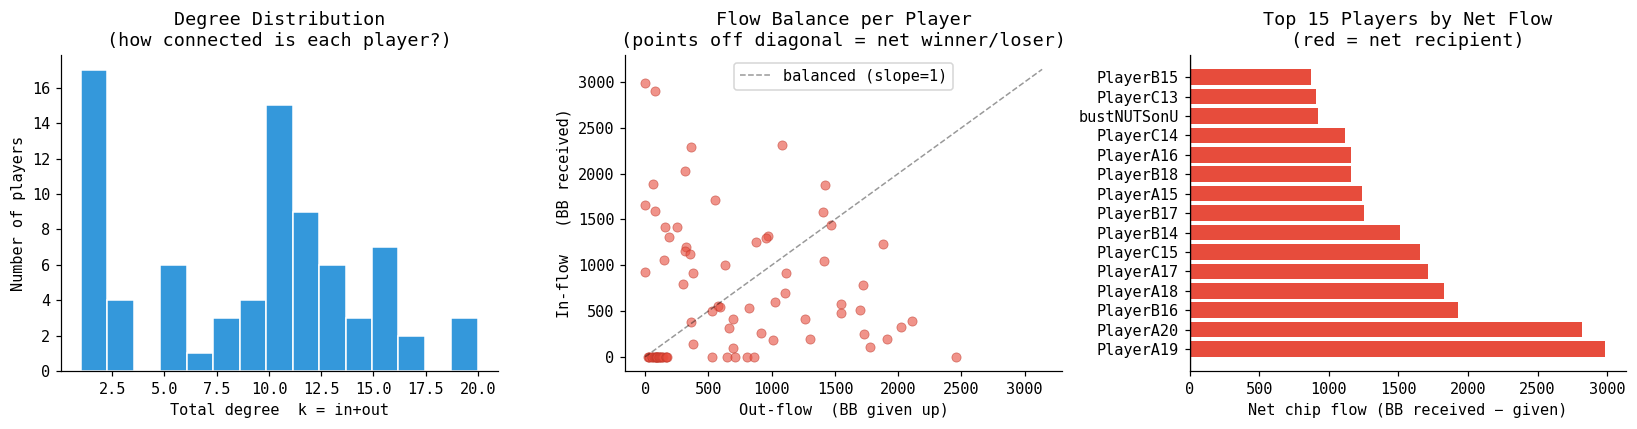

     player  in_degree  out_degree  in_flow_bb  out_flow_bb  net_flow
  PlayerA19         17           0      2988.0          0.0    2988.0
  PlayerA20         13           1      2899.0         78.0    2821.0
  PlayerB16         16           4      2289.0        361.0    1928.0
  PlayerA18          9           1      1889.0         59.0    1830.0
  PlayerA17         12           3      2028.0        313.0    1715.0
  PlayerC15         16           0      1653.0          0.0    1653.0
  PlayerB14         11           1      1587.0         75.0    1512.0
  PlayerB17         10           1      1413.0        156.0    1257.0
  PlayerA15         15           5      2316.0       1080.0    1236.0
  PlayerB18          9           3      1417.0        255.0    1162.0
  PlayerA16          9           4      1711.0        549.0    1162.0
  PlayerC14         12           1      1305.0        187.0    1118.0
bustNUTSonU          5           0       922.0          0.0     922.0
  PlayerC13         

In [7]:
# ── Section 3: Core Graph Metrics — Node & Edge Level ─────────────────────────
in_strength  = {n: sum(G_real[u][n]["weight"] for u in G_real.predecessors(n)) for n in G_real.nodes}
out_strength = {n: sum(G_real[n][v]["weight"] for v in G_real.successors(n)) for n in G_real.nodes}

df_nodes = pd.DataFrame({
    "player":       list(G_real.nodes),
    "in_degree":    [G_real.in_degree(n)  for n in G_real.nodes],
    "out_degree":   [G_real.out_degree(n) for n in G_real.nodes],
    "in_flow_bb":   [in_strength[n]       for n in G_real.nodes],
    "out_flow_bb":  [out_strength[n]      for n in G_real.nodes],
}).assign(net_flow=lambda d: d.in_flow_bb - d.out_flow_bb)\
  .sort_values("net_flow", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Degree distribution
all_deg = [G_real.in_degree(n) + G_real.out_degree(n) for n in G_real.nodes]
axes[0].hist(all_deg, bins=15, color="#3498db", edgecolor="white")
axes[0].set_xlabel("Total degree  k = in+out")
axes[0].set_ylabel("Number of players")
axes[0].set_title("Degree Distribution\n(how connected is each player?)")

# 2. In-flow vs Out-flow scatter
axes[1].scatter(df_nodes["out_flow_bb"], df_nodes["in_flow_bb"],
                alpha=0.6, color="#e74c3c", edgecolors="#c0392b", linewidths=0.5)
lim = max(df_nodes["out_flow_bb"].max(), df_nodes["in_flow_bb"].max()) * 1.05
axes[1].plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4, label="balanced (slope=1)")
axes[1].set_xlabel("Out-flow  (BB given up)")
axes[1].set_ylabel("In-flow   (BB received)")
axes[1].set_title("Flow Balance per Player\n(points off diagonal = net winner/loser)")
axes[1].legend()

# 3. Net flow bar: top 15 biggest winners
top15 = df_nodes.head(15)
bars = axes[2].barh(top15["player"], top15["net_flow"],
                    color=["#e74c3c" if v > 0 else "#3498db" for v in top15["net_flow"]])
axes[2].set_xlabel("Net chip flow (BB received − given)")
axes[2].set_title("Top 15 Players by Net Flow\n(red = net recipient)")
axes[2].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

print(df_nodes.to_string(index=False))

---
## Part 4 — Visualizing the Real Graph (Core Level)

The graph below shows **structure only** — no analytics overlaid yet.  
What we're looking for visually:
- **Tight clusters**: nodes that are closer to each other than to the rest
- **Bridge nodes**: a single node connecting two groups
- **Peripheral nodes**: rarely connected, small degree

This is exactly what Euler drew. Topology first.

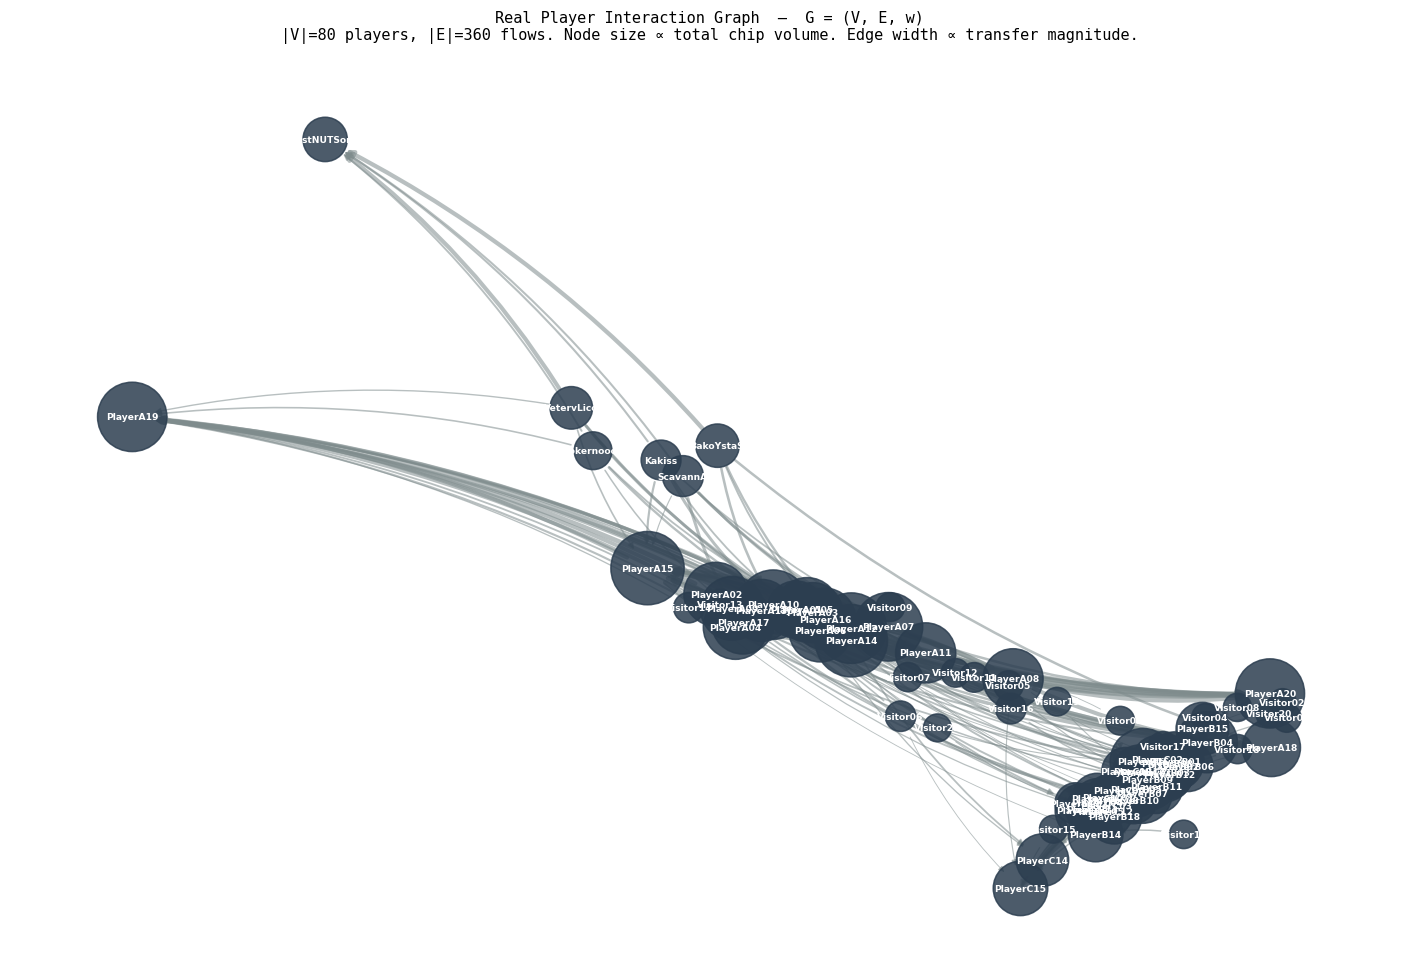

In [8]:
# ── Section 4: Core graph visualization — structure only ──────────────────────
# Use the undirected version for layout (direction shown via colour)
G_undirected = G_real.to_undirected()

# Filter to largest weakly connected component for clarity
largest_wcc = max(nx.weakly_connected_components(G_real), key=len)
G_lcc = G_real.subgraph(largest_wcc).copy()

# Node sizes proportional to total flow strength
total_strength = {n: (in_strength.get(n, 0) + out_strength.get(n, 0)) for n in G_lcc.nodes}
max_s  = max(total_strength.values()) or 1
sizes  = [300 + 2000 * total_strength[n] / max_s for n in G_lcc.nodes]

# Edge widths proportional to weight
e_weights = [G_lcc[u][v]["weight"] for u, v in G_lcc.edges]
max_ew = max(e_weights) if e_weights else 1
e_widths = [0.3 + 3.0 * w / max_ew for w in e_weights]

pos_lcc = nx.spring_layout(G_lcc, seed=7, k=2.0 / (len(G_lcc.nodes) ** 0.5))

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G_lcc, pos_lcc, ax=ax,
                       node_size=sizes, node_color="#2c3e50", alpha=0.85)
nx.draw_networkx_labels(G_lcc, pos_lcc, ax=ax,
                        font_color="white", font_size=6, font_weight="bold")
nx.draw_networkx_edges(G_lcc, pos_lcc, ax=ax,
                       width=e_widths, edge_color="#7f8c8d", alpha=0.55,
                       arrows=True, arrowsize=8,
                       connectionstyle="arc3,rad=0.1",
                       min_source_margin=15, min_target_margin=15)
ax.set_title(f"Real Player Interaction Graph  —  G = (V, E, w)\n"
             f"|V|={G_lcc.number_of_nodes()} players, "
             f"|E|={G_lcc.number_of_edges()} flows. "
             f"Node size ∝ total chip volume. Edge width ∝ transfer magnitude.",
             pad=14, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Part 5 — Flow Imbalance & Asymmetric Transfer Patterns

Two players who interact normally produce roughly symmetric chip flow over a large sample.  
Luck cancels out. Skill differences create modest asymmetry.

Collusion creates **structural asymmetry** — one player consistently feeds the other.

The formal measure for a pair $(i, j)$:

$$\Delta f_{ij} = w_{i \to j} - w_{j \to i}$$

When $|\Delta f_{ij}|$ is large relative to total volume, the pair is flagged.

Normalised version (used in the engine's scoring):

$$\text{imbalance}_{ij} = \frac{|\Delta f_{ij}|}{w_{i \to j} + w_{j \to i}}$$

Range: $[0, 1]$. A perfectly balanced pair = 0. A pure one-way feed = 1.

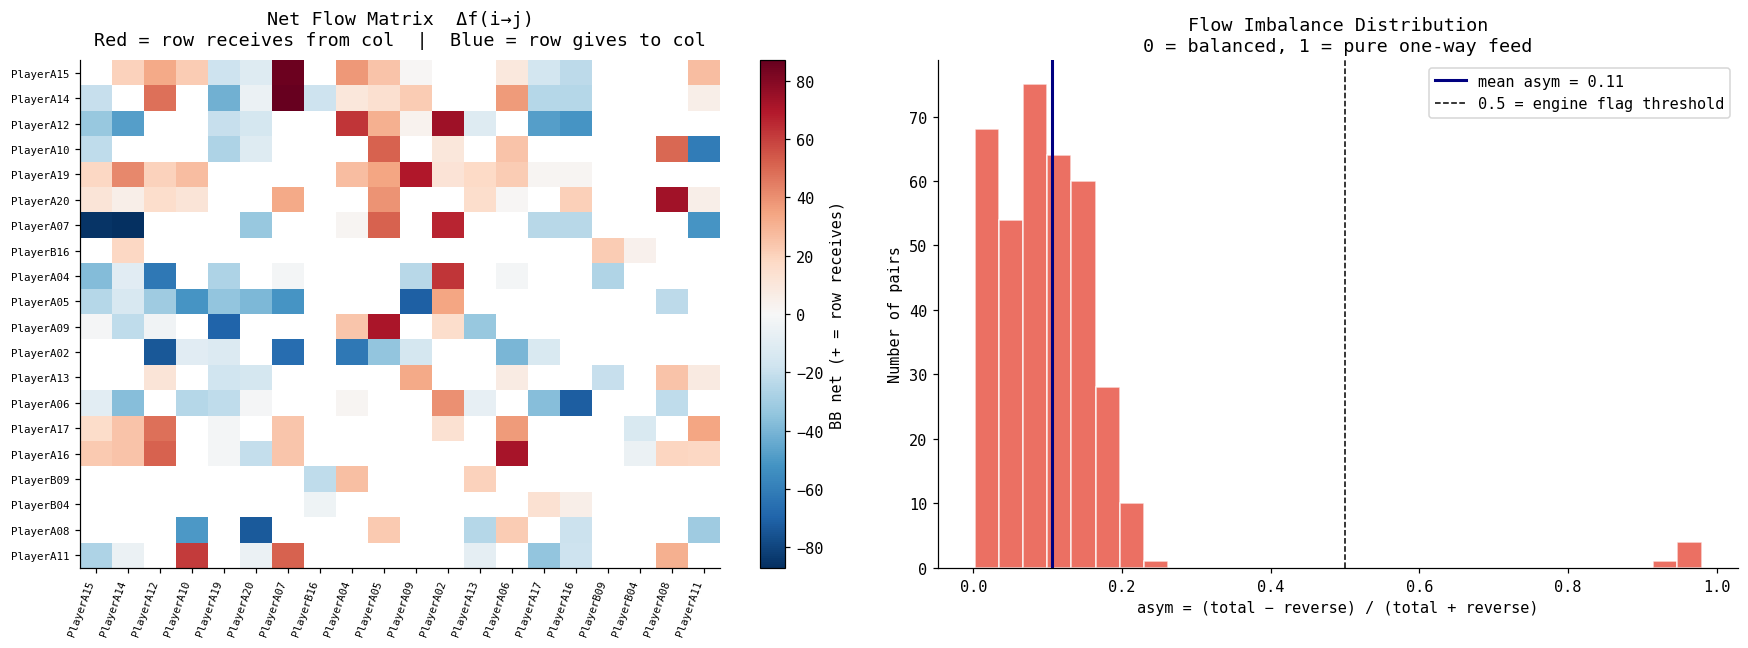

Pairs with asym > 0.5:  5
Pairs with asym > 0.7:  5

Most imbalanced pairs (highest asym):
     donor   recipient  total_transfer_bb  reverse_transfer_bb  imbalance_ratio  hands_together
 3akoYstaS bustNUTSonU              290.0                  3.0         0.979522             118
VetervLico bustNUTSonU              278.0                  3.0         0.978648             117
    Kakiss bustNUTSonU              123.0                  3.0         0.952381              99
  ScavannA bustNUTSonU              122.0                  3.0         0.952000              94
Pokernooob bustNUTSonU              109.0                  3.0         0.946429              79
 Visitor10   PlayerB14               80.0                 48.0         0.250000              66
 PlayerB11   PlayerB17               41.0                 26.0         0.223881              60
 Visitor03   PlayerC13               36.0                 23.0         0.220339              57
 Visitor17   PlayerC10               64.0    

In [9]:

# ── Section 5: Flow Imbalance ─────────────────────────────────────────────────
# Use the same simulated edge list built in Part 3.
# df_edges columns: donor, recipient, total_transfer_bb, reverse_transfer_bb,
#                   net_bb, asym (0=balanced, 1=pure dump), hands_together

df_flow = df_edges.rename(columns={"asym": "imbalance_ratio"}).copy()

# Heatmap: players × players — cell = net_bb  (+ = row player RECEIVES)
# Limit to top 20 players by total transfer volume for legibility
player_volume = (
    pd.concat([
        df_flow[["donor",     "total_transfer_bb"]].rename(columns={"donor":     "player", "total_transfer_bb": "vol"}),
        df_flow[["recipient", "total_transfer_bb"]].rename(columns={"recipient": "player", "total_transfer_bb": "vol"}),
    ])
    .groupby("player")["vol"].sum()
    .nlargest(20)
)
top_players = player_volume.index.tolist()

mat = pd.DataFrame(np.nan, index=top_players, columns=top_players)
for _, row in df_flow.iterrows():
    d, r, net = row["donor"], row["recipient"], row["net_bb"]
    if d in top_players and r in top_players:
        mat.loc[r, d] =  net
        mat.loc[d, r] = -net

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Net flow matrix ─────────────────────────────────────────────────────
vmax = mat.abs().max().max()
im = axes[0].imshow(mat.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(len(top_players)))
axes[0].set_xticklabels(top_players, rotation=70, ha="right", fontsize=7)
axes[0].set_yticks(range(len(top_players)))
axes[0].set_yticklabels(top_players, fontsize=7)
axes[0].set_title("Net Flow Matrix  Δf(i→j)\nRed = row receives from col  |  Blue = row gives to col", pad=10)
plt.colorbar(im, ax=axes[0], label="BB net (+ = row receives)")

# ── Right: Imbalance (asym) distribution ──────────────────────────────────────
axes[1].hist(df_flow["imbalance_ratio"], bins=30, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1].axvline(df_flow["imbalance_ratio"].mean(), color="navy", lw=2,
                label=f"mean asym = {df_flow['imbalance_ratio'].mean():.2f}")
axes[1].axvline(0.5, color="black", lw=1, ls="--", label="0.5 = engine flag threshold")
axes[1].set_xlabel("asym = (total − reverse) / (total + reverse)")
axes[1].set_ylabel("Number of pairs")
axes[1].set_title("Flow Imbalance Distribution\n0 = balanced, 1 = pure one-way feed")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pairs with asym > 0.5:  {(df_flow['imbalance_ratio'] > 0.5).sum()}")
print(f"Pairs with asym > 0.7:  {(df_flow['imbalance_ratio'] > 0.7).sum()}")
print()
print("Most imbalanced pairs (highest asym):")
print(df_flow.nlargest(10, "imbalance_ratio")[
    ["donor", "recipient", "total_transfer_bb", "reverse_transfer_bb", "imbalance_ratio", "hands_together"]
].to_string(index=False))


---
## Part 6 — Community Detection & Modularity

This is the formalisation of the "bubble" you observed.

**Modularity** $Q$ measures whether a network has meaningful community structure:

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Where:
- $A_{ij}$ = actual edge weight between nodes $i$ and $j$
- $k_i k_j / 2m$ = **expected** weight if edges were placed at random (null model)
- $\delta(c_i, c_j) = 1$ if both nodes are in the same community, else 0
- $m$ = total edge weight in the graph

**Interpretation of Q:**
| Q value | Meaning |
|---|---|
| $Q \leq 0$ | No community structure (random) |
| $0 < Q < 0.3$ | Weak structure |
| $0.3 \leq Q < 0.7$ | Moderate — meaningful communities |
| $Q \geq 0.7$ | Strong — tight isolated clusters |

A collusion ring produces high $Q$ because the colluders interact far more with each other than the null model predicts.

Modularity Q = 0.5278
Number of communities detected: 3

  Community 1: 30 members  avg_internal_weight=197.6bb
    → 3akoYstaS, Kakiss, PlayerA01, PlayerA02, PlayerA03, PlayerA04, PlayerA05, PlayerA06, PlayerA07, PlayerA08...
  Community 2: 27 members  avg_internal_weight=154.6bb
    → PlayerB01, PlayerB02, PlayerB03, PlayerB04, PlayerB05, PlayerB06, PlayerB07, PlayerB08, PlayerB09, PlayerB10...
  Community 3: 23 members  avg_internal_weight=110.8bb
    → PlayerC01, PlayerC02, PlayerC03, PlayerC04, PlayerC05, PlayerC06, PlayerC07, PlayerC08, PlayerC09, PlayerC10...


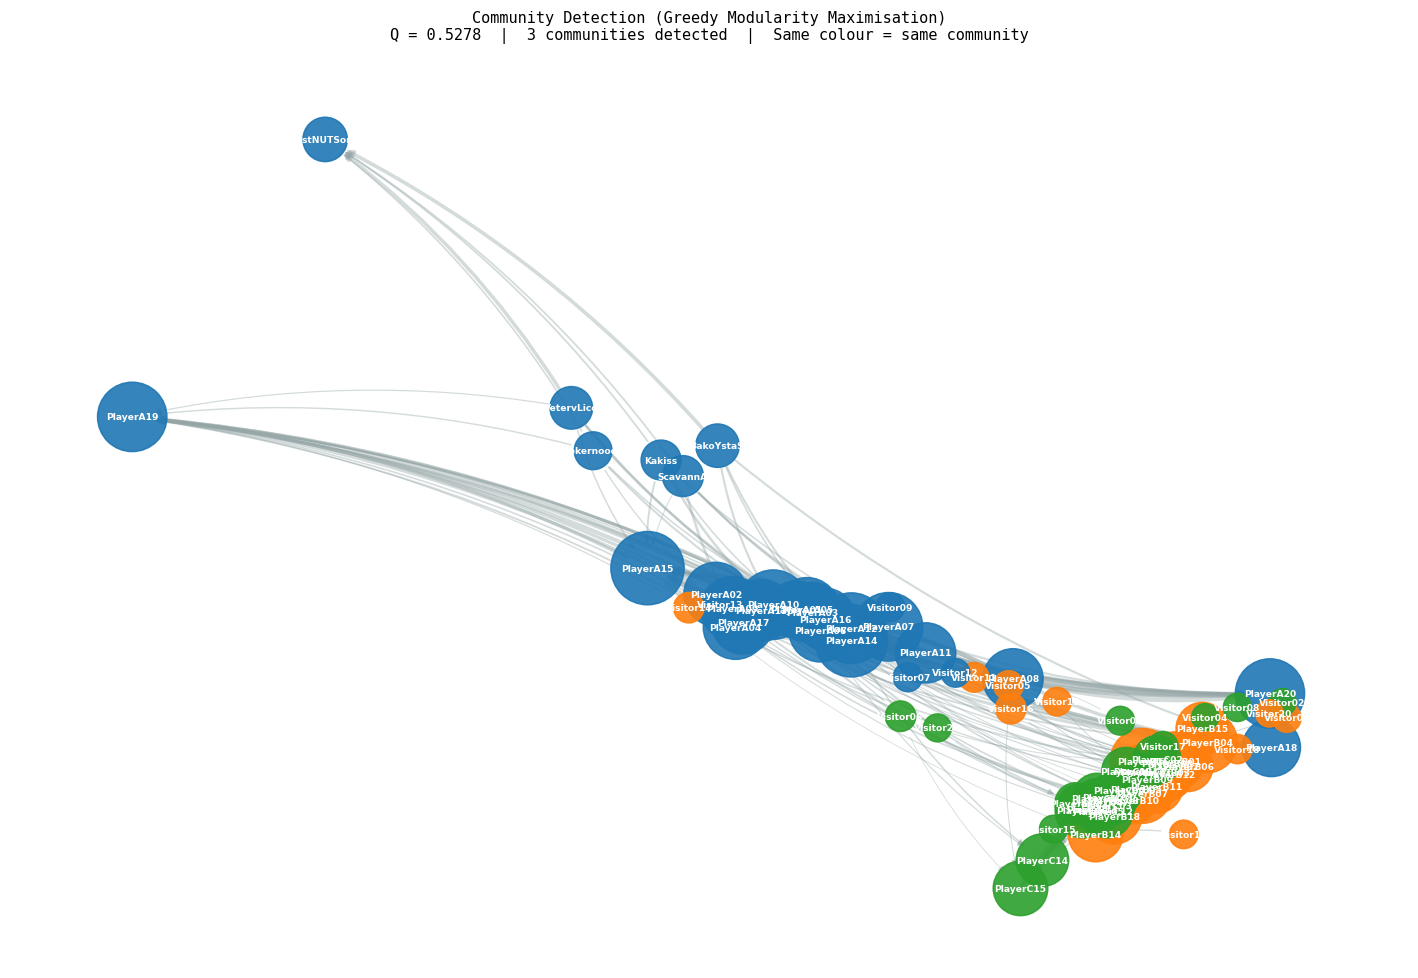

In [10]:
# ── Section 6: Community Detection on the Real Graph ─────────────────────────
# Use the undirected weighted version for modularity (standard convention)
G_uw = nx.Graph()
for u, v, d in G_lcc.edges(data=True):
    if G_uw.has_edge(u, v):
        G_uw[u][v]["weight"] += d["weight"]
    else:
        G_uw.add_edge(u, v, weight=d["weight"])

# Greedy modularity maximisation (built into NetworkX — no extra install)
communities = list(nx_comm.greedy_modularity_communities(G_uw, weight="weight"))
communities.sort(key=len, reverse=True)  # largest community first

Q = nx_comm.modularity(G_uw, communities, weight="weight")

print(f"Modularity Q = {Q:.4f}")
print(f"Number of communities detected: {len(communities)}")
print()
for i, comm in enumerate(communities[:6], 1):
    comm_sorted = sorted(comm)
    avg_internal = (
        G_uw.subgraph(comm).size(weight="weight") /
        max(G_uw.subgraph(comm).number_of_edges(), 1)
    ) if len(comm) > 1 else 0
    print(f"  Community {i}: {len(comm)} members  "
          f"avg_internal_weight={avg_internal:.1f}bb")
    print(f"    → {', '.join(comm_sorted[:10])}{'...' if len(comm)>10 else ''}")

# Assign community colour per node
palette = plt.cm.tab10.colors
node_community = {}
for idx, comm in enumerate(communities):
    for node in comm:
        node_community[node] = idx

node_colors_comm = [palette[node_community.get(n, 9) % 10] for n in G_lcc.nodes]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G_lcc, pos_lcc, ax=ax,
                       node_size=sizes, node_color=node_colors_comm, alpha=0.9)
nx.draw_networkx_labels(G_lcc, pos_lcc, ax=ax,
                        font_color="white", font_size=6, font_weight="bold")
nx.draw_networkx_edges(G_lcc, pos_lcc, ax=ax,
                       width=[0.3 + 2.5 * w / max_ew for w in e_weights],
                       edge_color="#95a5a6", alpha=0.4, arrows=True,
                       arrowsize=8, connectionstyle="arc3,rad=0.1",
                       min_source_margin=15, min_target_margin=15)
ax.set_title(f"Community Detection (Greedy Modularity Maximisation)\n"
             f"Q = {Q:.4f}  |  {len(communities)} communities detected  "
             f"|  Same colour = same community",
             pad=14, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

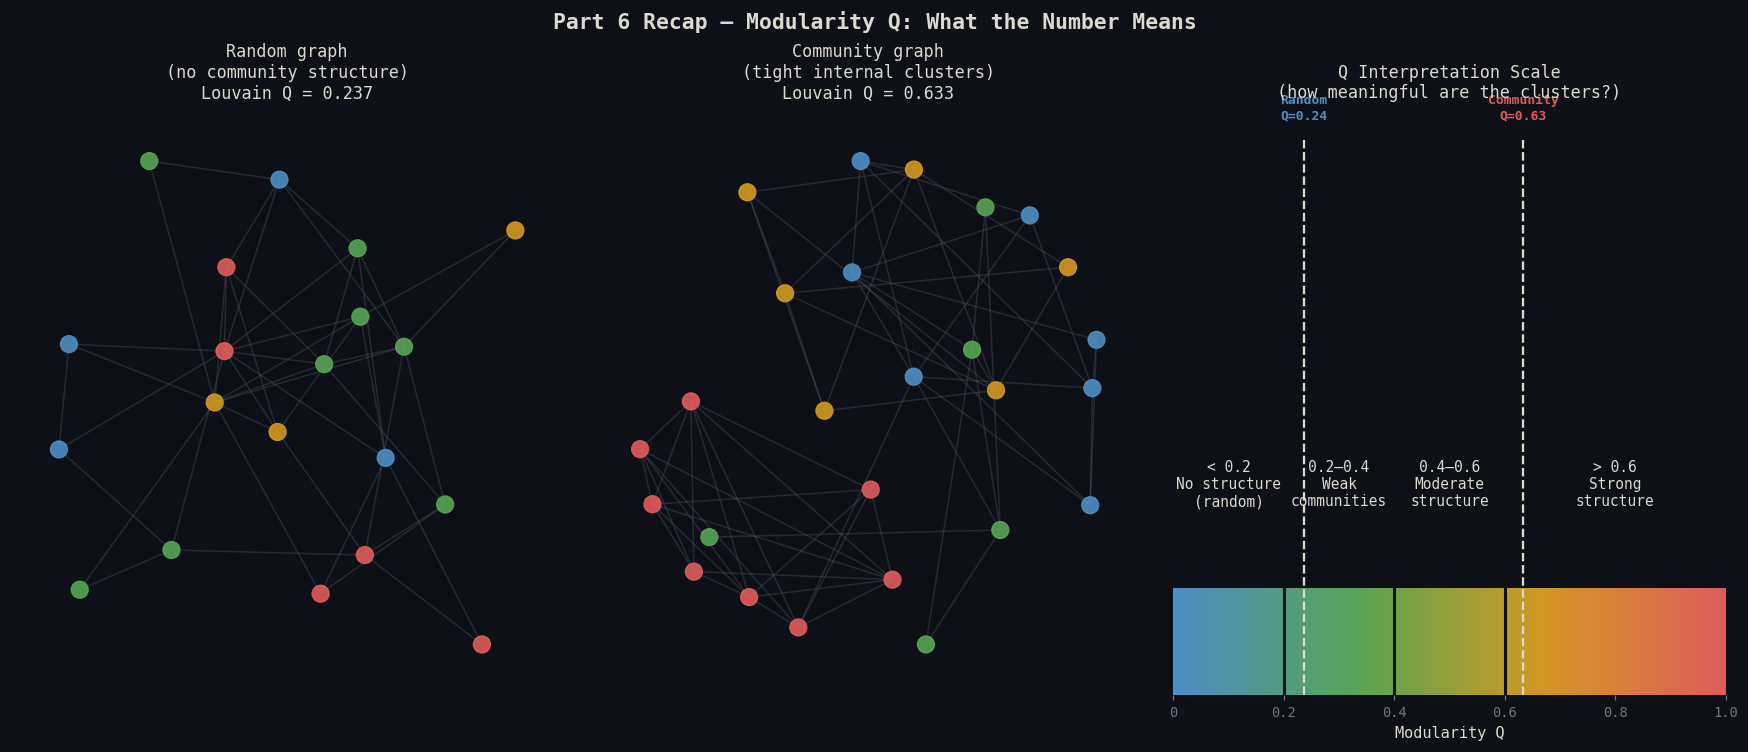

Random graph:     Q = 0.237  → no meaningful cluster structure
Community graph:  Q = 0.633  → strong meaningful community structure

In a collusion context:
  High Q means the chip-flow graph has REAL groups.
  A colluding ring sits inside one of those groups with elevated internal volume.


In [11]:

# ── Part 6 Recap: Modularity Q — What Does It Actually Mean? ──────────────────
# Two mini synthetic graphs: one random (Q≈0), one with tight communities (Q≈0.8)
# Placed side-by-side with an annotated Q interpretation scale

BG = "#0d1117"; WHITE = "#ddd8d0"; DIM = "#6e7681"
PALETTE = ["#e05c5c", "#4d8ec4", "#d29922", "#58a454"]

rng_r = np.random.default_rng(7)

# ─── Build two toy graphs ────────────────────────────────────────────────────
def build_random_graph(n=20, p=0.18):
    G = nx.erdos_renyi_graph(n, p, seed=7, directed=False)
    for nd in G.nodes:
        G.nodes[nd]["comm"] = rng_r.integers(0, 4)
    return G

def build_community_graph(sizes=(8, 7, 6, 5)):
    G = nx.Graph()
    colour = {}
    node_id = 0
    for c_idx, sz in enumerate(sizes):
        members = list(range(node_id, node_id + sz))
        for i in members:
            G.add_node(i)
            colour[i] = c_idx
        for i in members:
            for j in members:
                if i < j and rng_r.random() < 0.75:
                    G.add_edge(i, j)
        node_id += sz
    # sparse cross-community edges
    for _ in range(5):
        a = rng_r.integers(0, node_id)
        b = rng_r.integers(0, node_id)
        if a != b and colour[a] != colour[b]:
            G.add_edge(a, b)
    nx.set_node_attributes(G, colour, "comm")
    return G

G_rand = build_random_graph()
G_comm = build_community_graph()

def modularity_score(G):
    comms = nx_comm.louvain_communities(G, seed=42)
    return nx_comm.modularity(G, comms)

Q_rand = modularity_score(G_rand)
Q_comm = modularity_score(G_comm)

pos_rand = nx.spring_layout(G_rand, seed=3)
pos_comm = nx.spring_layout(G_comm, seed=9, k=1.8)

# ─── Figure ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7), facecolor=BG)
fig.suptitle("Part 6 Recap — Modularity Q: What the Number Means",
             fontsize=14, fontweight="bold", color=WHITE, y=0.97)

ax_rand = fig.add_subplot(1, 3, 1, facecolor=BG)
ax_comm = fig.add_subplot(1, 3, 2, facecolor=BG)
ax_scale = fig.add_subplot(1, 3, 3, facecolor=BG)

def draw_mini_graph(ax, G, pos, title, Q):
    node_c = [PALETTE[G.nodes[n]["comm"] % 4] for n in G.nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, edge_color="#555566", width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_c, node_size=120, alpha=0.9)
    ax.set_title(f"{title}\nLouvain Q = {Q:.3f}", color=WHITE, fontsize=11, pad=8)
    ax.set_facecolor(BG)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

draw_mini_graph(ax_rand, G_rand, pos_rand, "Random graph\n(no community structure)", Q_rand)
draw_mini_graph(ax_comm, G_comm, pos_comm, "Community graph\n(tight internal clusters)", Q_comm)

# ── Q interpretation color bar ────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("q", ["#4d8ec4","#58a454","#d29922","#e05c5c"])

q_vals  = np.linspace(0, 1, 300)
bar_img = np.vstack([q_vals, q_vals])
ax_scale.imshow(bar_img, aspect="auto", cmap=cmap,
                extent=[0, 1, 0, 0.2], origin="lower")

zones = [
    (0.00, 0.20, "#4d8ec4", "< 0.2\nNo structure\n(random)"),
    (0.20, 0.40, "#58a454", "0.2–0.4\nWeak\ncommunities"),
    (0.40, 0.60, "#d29922", "0.4–0.6\nModerate\nstructure"),
    (0.60, 1.00, "#e05c5c", "> 0.6\nStrong\nstructure"),
]
for lo, hi, col, label in zones:
    mid = (lo + hi) / 2
    ax_scale.text(mid, 0.35, label, ha="center", va="bottom",
                  fontsize=9.5, color=WHITE, fontfamily="monospace",
                  multialignment="center")
    if lo > 0:
        ax_scale.axvline(lo, ymin=0, ymax=0.35, color=BG, lw=2)

# Annotate our two graphs
for Q_val, lbl, col in [(Q_rand, f"Random\nQ={Q_rand:.2f}", "#4d8ec4"),
                         (Q_comm, f"Community\nQ={Q_comm:.2f}", "#e05c5c")]:
    ax_scale.axvline(Q_val, ymin=0, ymax=0.95, color=WHITE, lw=1.5, ls="--")
    ax_scale.text(Q_val, 0.98, lbl, ha="center", va="bottom",
                  fontsize=8.5, color=col, fontweight="bold", multialignment="center",
                  transform=ax_scale.get_xaxis_transform())

ax_scale.set_xlim(0, 1)
ax_scale.set_ylim(0, 1.1)
ax_scale.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax_scale.set_xticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1.0"], color=DIM, fontsize=9)
ax_scale.set_yticks([])
ax_scale.set_xlabel("Modularity Q", color=WHITE, fontsize=10)
ax_scale.set_title("Q Interpretation Scale\n(how meaningful are the clusters?)",
                    color=WHITE, fontsize=11, pad=8)
for spine in ax_scale.spines.values(): spine.set_visible(False)
ax_scale.tick_params(colors=DIM)

plt.tight_layout()
plt.show()

print(f"Random graph:     Q = {Q_rand:.3f}  → no meaningful cluster structure")
print(f"Community graph:  Q = {Q_comm:.3f}  → strong meaningful community structure")
print()
print("In a collusion context:")
print("  High Q means the chip-flow graph has REAL groups.")
print("  A colluding ring sits inside one of those groups with elevated internal volume.")


---
## Part 7 — Subgraph Density: Cluster vs. Field

Modularity tells us communities *exist*.  
**Subgraph density** tells us *how tight* each one is.

$$d(S) = \frac{|E(S)|}{\binom{|S|}{2}} = \frac{2|E(S)|}{|S|(|S|-1)}$$

Where $E(S)$ = edges whose **both** endpoints are in subgraph $S$.

A complete graph (everyone connected to everyone) has $d = 1$.  
A sparse random subgraph has $d \approx \text{global density}$.

The key comparison is:
$$d(\text{suspected cluster}) \gg d(\text{full graph})$$

If the cluster density is many times the global density, it's not random.

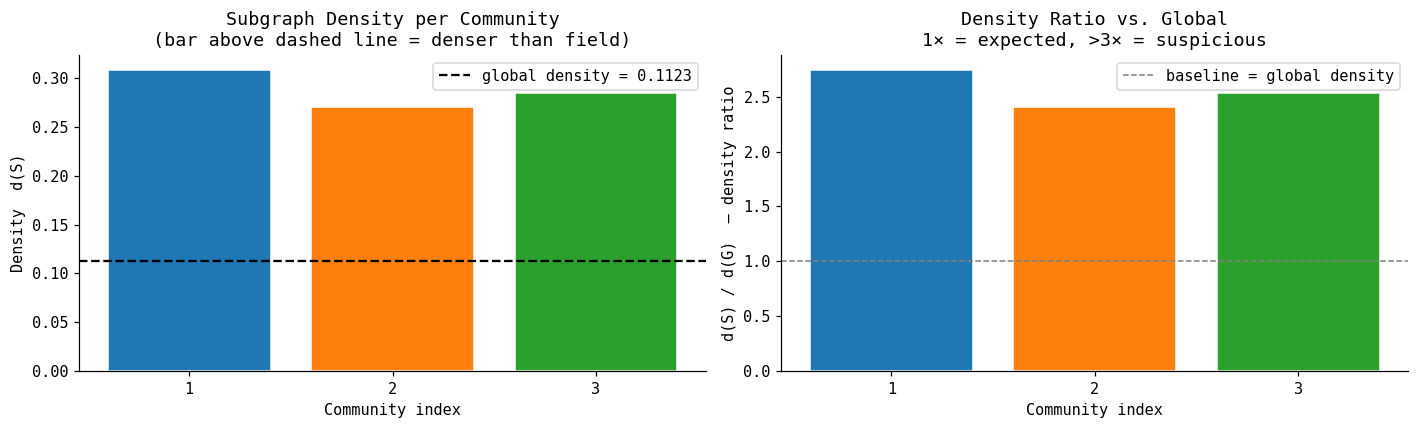

 community  members  internal_edges  internal_vol_bb  density  density_ratio
         1       30             134          26479.0 0.308046       2.742043
         2       27              95          14685.0 0.270655       2.409213
         3       23              72           7979.0 0.284585       2.533207


In [12]:
# ── Section 7: Subgraph Density Analysis ─────────────────────────────────────
global_density = nx.density(G_uw)

rows = []
for i, comm in enumerate(communities, 1):
    sub = G_uw.subgraph(comm)
    d   = nx.density(sub)
    n   = sub.number_of_nodes()
    e   = sub.number_of_edges()
    total_w = sub.size(weight="weight")
    rows.append({
        "community":      i,
        "members":        n,
        "internal_edges": e,
        "internal_vol_bb":total_w,
        "density":        d,
        "density_ratio":  d / global_density if global_density > 0 else np.nan,
    })

df_density = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: density per community
colors_d = [palette[i % 10] for i in range(len(df_density))]
axes[0].bar(df_density["community"].astype(str), df_density["density"],
            color=colors_d, edgecolor="white")
axes[0].axhline(global_density, color="black", lw=1.5, ls="--",
                label=f"global density = {global_density:.4f}")
axes[0].set_xlabel("Community index")
axes[0].set_ylabel("Density  d(S)")
axes[0].set_title("Subgraph Density per Community\n(bar above dashed line = denser than field)")
axes[0].legend()

# Bar: density ratio (how many x denser than the global)
axes[1].bar(df_density["community"].astype(str), df_density["density_ratio"],
            color=colors_d, edgecolor="white")
axes[1].axhline(1.0, color="gray", lw=1, ls="--", label="baseline = global density")
axes[1].set_xlabel("Community index")
axes[1].set_ylabel("d(S) / d(G)  — density ratio")
axes[1].set_title("Density Ratio vs. Global\n1× = expected, >3× = suspicious")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_density.to_string(index=False))

---
## Part 8 — Centrality Analysis: Who Matters Most?

Centrality measures **importance** of a node in a network.  
Three distinct definitions, each answering a different question:

| Metric | Definition | What it finds |
|---|---|---|
| **Degree centrality** | $C_D(v) = \frac{\deg(v)}{n-1}$ | Most-connected players |
| **Betweenness centrality** | $C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$ | Bridge players — critical links between clusters |
| **Eigenvector centrality** | $C_E(v) = \frac{1}{\lambda} \sum_{u \in N(v)} C_E(u)$ | Players connected to other high-centrality players |

In a collusion ring:
- **The account player** (chip sink) has high in-degree, high eigenvector centrality
- **The bridge player** (who brings outsiders in) has high betweenness centrality
- **Peripheral feeders** have low degree but high flow imbalance

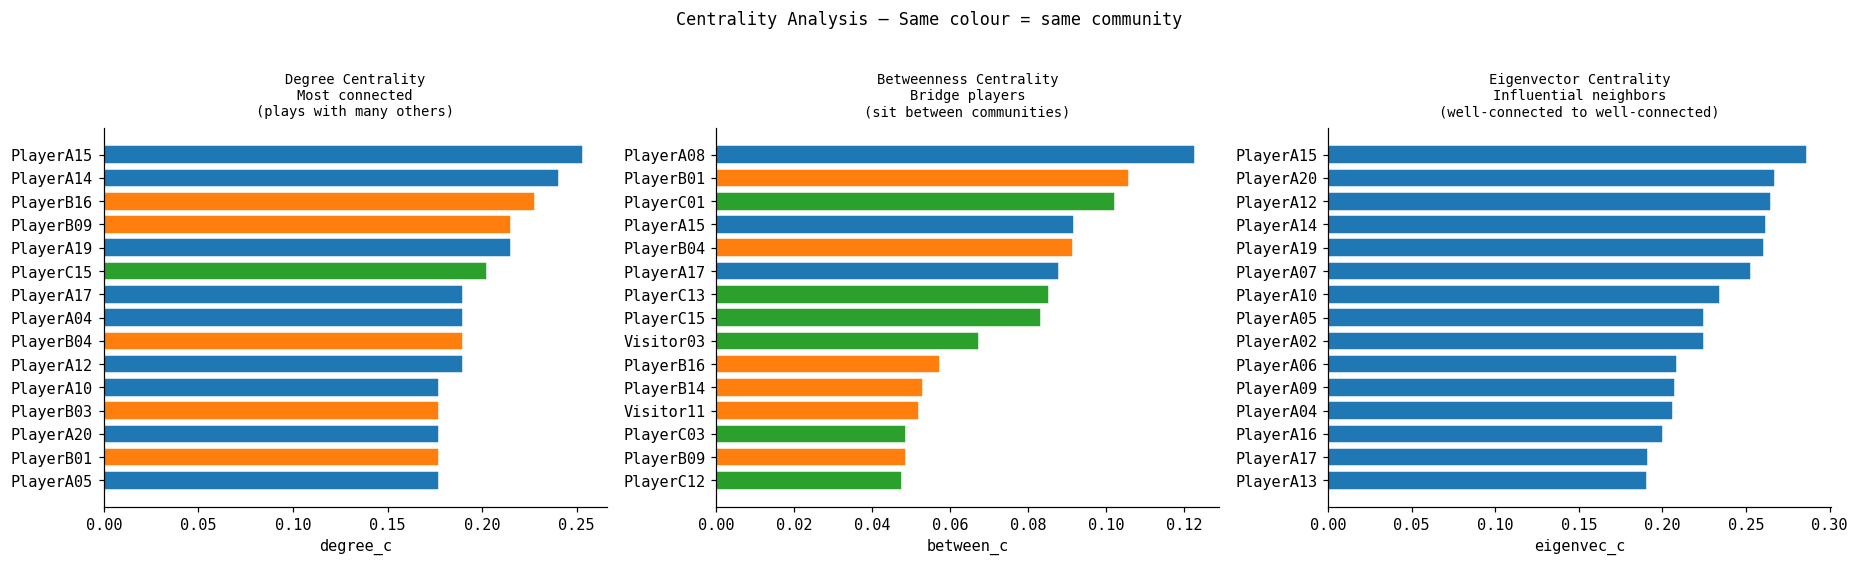


Top 10 players by eigenvector centrality:
   player  degree_c  between_c  eigenvec_c  community
PlayerA15  0.253165   0.091691    0.286580          0
PlayerA20  0.177215   0.008439    0.267466          0
PlayerA12  0.189873   0.035378    0.265038          0
PlayerA14  0.240506   0.034242    0.261946          0
PlayerA19  0.215190   0.045602    0.261012          0
PlayerA07  0.151899   0.000000    0.252939          0
PlayerA10  0.177215   0.015904    0.234511          0
PlayerA05  0.177215   0.026615    0.225150          0
PlayerA02  0.151899   0.024180    0.225011          0
PlayerA06  0.164557   0.011360    0.208467          0


In [13]:
# ── Section 8: Centrality Analysis ───────────────────────────────────────────
deg_c       = nx.degree_centrality(G_uw)
between_c   = nx.betweenness_centrality(G_uw, weight="weight", normalized=True)
try:
    eigen_c = nx.eigenvector_centrality(G_uw, weight="weight", max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigen_c = {n: 0.0 for n in G_uw.nodes}

df_cent = pd.DataFrame({
    "player":       list(G_uw.nodes),
    "degree_c":     [deg_c[n]     for n in G_uw.nodes],
    "between_c":    [between_c[n] for n in G_uw.nodes],
    "eigenvec_c":   [eigen_c[n]   for n in G_uw.nodes],
    "community":    [node_community.get(n, -1) for n in G_uw.nodes],
}).sort_values("eigenvec_c", ascending=False)

TOP_N = min(15, len(df_cent))
top_players_cent = df_cent.head(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = [
    ("degree_c",   "Degree Centrality",      "Most connected\n(plays with many others)"),
    ("between_c",  "Betweenness Centrality",  "Bridge players\n(sit between communities)"),
    ("eigenvec_c", "Eigenvector Centrality",  "Influential neighbors\n(well-connected to well-connected)"),
]

for ax, (col, title, subtitle) in zip(axes, metrics):
    df_plot = df_cent.nlargest(TOP_N, col).sort_values(col)
    comm_colors = [palette[df_cent.loc[df_cent.player==p, "community"].values[0] % 10]
                   for p in df_plot["player"]]
    ax.barh(df_plot["player"], df_plot[col], color=comm_colors, edgecolor="white")
    ax.set_xlabel(col)
    ax.set_title(f"{title}\n{subtitle}", fontsize=9, pad=8)

plt.suptitle("Centrality Analysis — Same colour = same community",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 10 players by eigenvector centrality:")
print(df_cent[["player","degree_c","between_c","eigenvec_c","community"]].head(10).to_string(index=False))

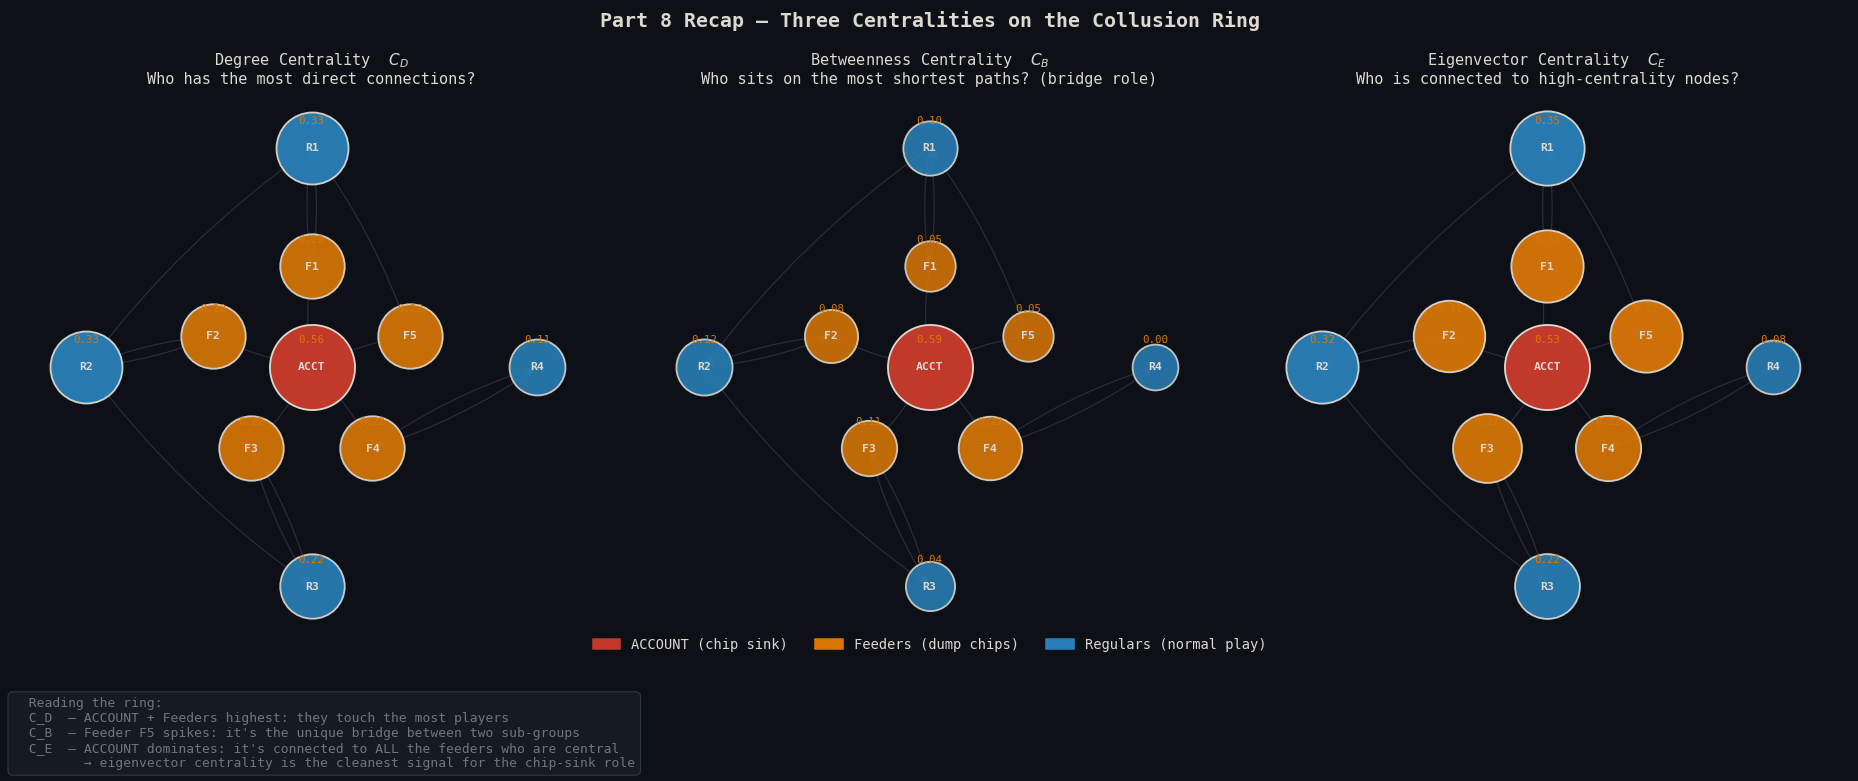

In [14]:

# ── Part 8 Recap: The Three Centralities On the Ring ─────────────────────────
# Same 6-node collusion ring + 4 regulars.
# Three panels: one per centrality type — each annotated with what it measures.

BG = "#0d1117"; WHITE = "#ddd8d0"; DIM = "#6e7681"
CRED = "#c0392b"; CBLUE = "#2980b9"; CAMBER = "#d97706"; CGRAY = "#555566"

# ─── Build annotated ring graph ───────────────────────────────────────────────
G8 = nx.DiGraph()
ACCOUNT_8  = "ACCOUNT"
FEEDERS_8  = ["F1","F2","F3","F4","F5"]
REGS_8     = ["R1","R2","R3","R4"]
ALL_8      = [ACCOUNT_8] + FEEDERS_8 + REGS_8

# Feeder → Account (dump edges, heavy)
for f in FEEDERS_8:
    G8.add_edge(f, ACCOUNT_8, weight=150)

# Regulars ↔ Feeders (normal play, light)
G8.add_edge("R1", "F1", weight=30); G8.add_edge("F1", "R1", weight=28)
G8.add_edge("R2", "F2", weight=25); G8.add_edge("F2", "R2", weight=22)
G8.add_edge("R3", "F3", weight=40); G8.add_edge("F3", "R3", weight=38)
G8.add_edge("R4", "F4", weight=20); G8.add_edge("F4", "R4", weight=18)
# One feeder bridges two groups
G8.add_edge("F5", "R1", weight=15); G8.add_edge("R1", "R2", weight=12)
G8.add_edge("R2", "R3", weight=10)

G8_uw = G8.to_undirected()

# ─── Layout (shared across panels) ───────────────────────────────────────────
fixed_pos = {"ACCOUNT": (0.0, 0.0)}
for i, f in enumerate(FEEDERS_8):
    angle = np.pi/2 + i * 2*np.pi/5
    fixed_pos[f] = (0.55*np.cos(angle), 0.55*np.sin(angle))
for i, r in enumerate(REGS_8):
    angle = np.pi/2 + i * np.pi/2
    fixed_pos[r] = (1.2*np.cos(angle), 1.2*np.sin(angle))

# ─── Centrality measures ──────────────────────────────────────────────────────
degree_c  = nx.degree_centrality(G8_uw)
between_c = nx.betweenness_centrality(G8_uw, normalized=True)
try:
    eigen_c = nx.eigenvector_centrality(G8_uw, max_iter=500)
except nx.PowerIterationFailedConvergence:
    eigen_c = {n: 0.0 for n in G8_uw.nodes}

def node_col(n):
    if n == ACCOUNT_8: return CRED
    if n in FEEDERS_8: return CAMBER
    return CBLUE

def draw_panel(ax, scores, title, subtitle, color_by_score=True):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

    max_s = max(scores.values()) or 1
    for u_, v_ in G8.edges():
        x0,y0 = fixed_pos[u_]; x1,y1 = fixed_pos[v_]
        ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle="-|>", color=CGRAY,
                                   lw=0.8, alpha=0.4,
                                   connectionstyle="arc3,rad=0.08"))

    for node in ALL_8:
        x, y = fixed_pos[node]
        sc   = scores.get(node, 0)
        sz   = 900 + 2200 * sc / max_s
        col  = node_col(node) if not color_by_score else node_col(node)
        alpha_edge = 0.85 + 0.15 * (sc / max_s)
        ax.scatter(x, y, s=sz, color=col, alpha=alpha_edge,
                   edgecolors=WHITE, linewidths=1.2, zorder=5)
        label = node if node != ACCOUNT_8 else "ACCT"
        ax.text(x, y, label, ha="center", va="center",
                fontsize=7.5, fontweight="bold", color=WHITE, zorder=6)
        # score annotation above node
        ax.text(x, y + 0.12, f"{sc:.2f}", ha="center", va="bottom",
                fontsize=7, color=CAMBER, fontfamily="monospace", zorder=7)

    ax.set_title(f"{title}\n{subtitle}", color=WHITE, fontsize=10, pad=6)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.5, 1.5)

# ─── Render ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor=BG)
fig.suptitle("Part 8 Recap — Three Centralities on the Collusion Ring",
             fontsize=13, fontweight="bold", color=WHITE, y=0.98)

draw_panel(axes[0], degree_c,  "Degree Centrality  $C_D$",
           "Who has the most direct connections?")
draw_panel(axes[1], between_c, "Betweenness Centrality  $C_B$",
           "Who sits on the most shortest paths? (bridge role)")
draw_panel(axes[2], eigen_c,   "Eigenvector Centrality  $C_E$",
           "Who is connected to high-centrality nodes?")

# ─── Legend strip ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
handles = [Patch(color=CRED,   label="ACCOUNT (chip sink)"),
           Patch(color=CAMBER, label="Feeders (dump chips)"),
           Patch(color=CBLUE,  label="Regulars (normal play)")]
fig.legend(handles=handles, loc="lower center", ncol=3,
           framealpha=0, labelcolor=WHITE, fontsize=9,
           bbox_to_anchor=(0.5, -0.01))

# ─── Interpretation box ───────────────────────────────────────────────────────
interp = "\n".join([
    "  Reading the ring: ",
    "  C_D  — ACCOUNT + Feeders highest: they touch the most players",
    "  C_B  — Feeder F5 spikes: it's the unique bridge between two sub-groups",
    "  C_E  — ACCOUNT dominates: it's connected to ALL the feeders who are central",
    "         → eigenvector centrality is the cleanest signal for the chip-sink role",
])
fig.text(0.01, -0.06, interp, ha="left", va="top",
         fontsize=8.5, color=DIM, fontfamily="monospace",
         wrap=True, bbox=dict(boxstyle="round,pad=0.4", fc="#161b22", ec="#30363d", lw=0.8))

plt.tight_layout()
plt.show()



---
## Part 9 — From Notebook to Engine: The Structural Architecture

This section is the architectural specification — how the graph theory developed in Parts 1–8 maps to a detection pipeline.

### The Fundamental Design Problem

A naive implementation recomputes the graph on every API request.  
This creates three structural problems:

1. **Dual data sources** — if the notebook and the API compute the same graph from different inputs, they can drift and disagree
2. **No persistence** — community assignments, centrality scores, and $Q$ are never stored; any restart discards history
3. **Signal isolation** — chip flow and behavioral signals live in separate tables; no unified per-pair input exists for the graph layer

The correct design separates these into four distinct layers.

### The Correct Four-Layer Architecture

```
Layer 0  Raw hand results                  ← immutable, append-only

Layer 1  Signal computation                ← runs in pipeline
         compute_pair_chipflow()           → pair_chipflow  (per-pair volumes, asym)
         ChipFlowPattern    ┐
         BehavioralShift    ├──────────── → collusion_pair_flags  (per-pair flag scores)
         ActionAttributed   ┘

Layer 2  Graph input                       ← single canonical VIEW
         pair_evidence = JOIN(pair_chipflow, collusion_pair_flags)
         → one row per ordered pair, all signal scores unified
         → canonical input for ALL graph construction

Layer 3  Graph layer                       ← runs in pipeline, not at request time
         build_graph_layer() reads pair_evidence
         stores → pair_graph_nodes         (centrality, role, community_id)
                  pair_graph_communities   (Q, members, risk_score)

Layer 4  Serving                           ← reads stored Layer 3 output
         /api/network/* endpoints  → reads pair_graph_nodes + communities (no recompute)
         This notebook             → reads same tables (verification = structural test)
```

### What `pair_evidence` Should Contain

One row per ordered pair with:

| Column | Source | Description |
|---|---|---|
| `player_a`, `player_b` | pair_chipflow | Ordered pair identity |
| `total_transfer_bb` | pair_chipflow | Dominant direction volume |
| `chip_flow_asym` | pair_chipflow | $(total - reverse) / (total + reverse)$ |
| `chip_flow_score` | collusion_pair_flags | Chip-flow flag score (0 if not triggered) |
| `behavioral_score` | collusion_pair_flags | Behavioral shift score |
| `composite_score` | computed | Weighted sum: 50% chip + 30% behavioral + 20% action |

### Importance Tier Model

Not all pairs warrant graph analysis. The tier filter focuses computation:

| Tier | Condition | Action |
|---|---|---|
| **CRITICAL** | `composite_score > 0` (any flag triggered) | Full graph + community audit |
| **ELEVATED** | `asym > 0.70` AND `volume > 50 bb` | Community membership check |
| **WATCH** | `volume > 200 bb` OR `asym > 0.55` | Monitor in next pipeline run |
| **BASELINE** | all others | No action |

### Role of This Notebook in the Architecture

Once the four-layer design is fully implemented:

- **Parts 1–2** remain as the mathematical specification — what the pipeline *must* satisfy
- **Parts 3–8** become the verification layer — asserting the pipeline's graph output matches the theory
- **Parts 9–10** become integration tests — any divergence between notebook and API signals a structural bug
- **This document** serves as the ground truth for reviewers and engineers onboarding to the detection system


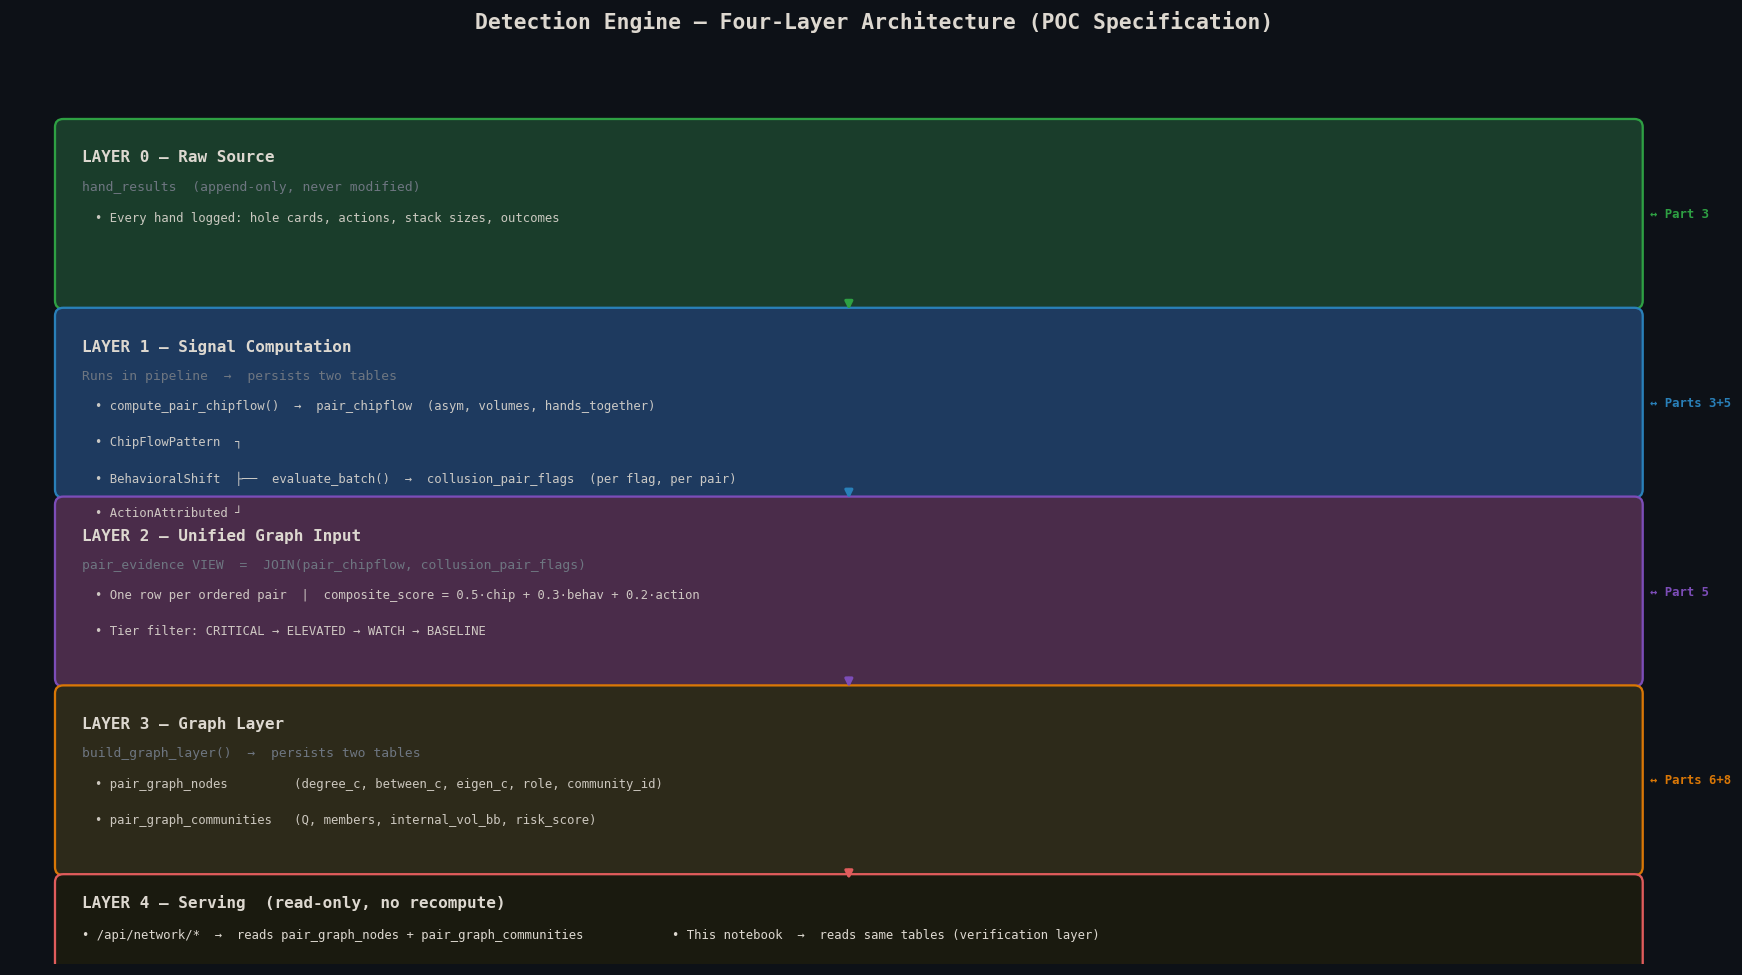

Importance Tier Distribution (simulated 80-player dataset)
────────────────────────────────────────────────────
  🔴 CRITICAL       5 pairs  (  1.4%)
  🟠 ELEVATED       0 pairs  (  0.0%)
  🟡 WATCH         90 pairs  ( 24.7%)
  ⬜ BASELINE     270 pairs  ( 74.0%)
────────────────────────────────────────────────────
     Total          365 pairs

CRITICAL pairs:
     donor   recipient  total_transfer_bb  asym
VetervLico bustNUTSonU              278.0 0.979
 3akoYstaS bustNUTSonU              290.0 0.980
    Kakiss bustNUTSonU              123.0 0.952
  ScavannA bustNUTSonU              122.0 0.952
Pokernooob bustNUTSonU              109.0 0.946


In [15]:

# ── Part 9 Visualisation: Four-Layer Architecture Diagram ────────────────────
# No database — pure matplotlib annotation diagram
# Shows how Parts 1-8 concepts connect to the pipeline design

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BG     = "#0d1117"; WHITE  = "#ddd8d0"; DIM = "#6e7681"
LAYER_COLORS = ["#1a3d2b","#1e3a5f","#4a2c4a","#2d2a1a"]
LAYER_BORDERS= ["#2ea043","#2980b9","#7c4db8","#d97706"]
ACCENT       = ["#58a454","#4d8ec4","#9b59b6","#d97706"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor=BG)
ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 16); ax.set_ylim(0, 9)

fig.suptitle("Detection Engine — Four-Layer Architecture (POC Specification)",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

layers = [
    (0, "LAYER 0 — Raw Source",
     "hand_results  (append-only, never modified)",
     ["Every hand logged: hole cards, actions, stack sizes, outcomes"],
     "#1a3d2b", "#2ea043"),
    (1, "LAYER 1 — Signal Computation",
     "Runs in pipeline  →  persists two tables",
     ["compute_pair_chipflow()  →  pair_chipflow  (asym, volumes, hands_together)",
      "ChipFlowPattern  ┐",
      "BehavioralShift  ├──  evaluate_batch()  →  collusion_pair_flags  (per flag, per pair)",
      "ActionAttributed ┘"],
     "#1e3a5f", "#2980b9"),
    (2, "LAYER 2 — Unified Graph Input",
     "pair_evidence VIEW  =  JOIN(pair_chipflow, collusion_pair_flags)",
     ["One row per ordered pair  |  composite_score = 0.5·chip + 0.3·behav + 0.2·action",
      "Tier filter: CRITICAL → ELEVATED → WATCH → BASELINE"],
     "#4a2c4a", "#7c4db8"),
    (3, "LAYER 3 — Graph Layer",
     "build_graph_layer()  →  persists two tables",
     ["pair_graph_nodes         (degree_c, between_c, eigen_c, role, community_id)",
      "pair_graph_communities   (Q, members, internal_vol_bb, risk_score)"],
     "#2d2a1a", "#d97706"),
]

layer_h = 1.7
gap     = 0.15
y_start = 8.2

def draw_box(ax, x0, y0, w, h, fc, ec, title, subtitle, bullets):
    patch = FancyBboxPatch((x0, y0), w, h,
                           boxstyle="round,pad=0.08",
                           facecolor=fc, edgecolor=ec, linewidth=1.5, zorder=2)
    ax.add_patch(patch)
    ax.text(x0+0.18, y0+h-0.22, title,
            fontsize=10.5, fontweight="bold", color=WHITE, va="top", zorder=3)
    ax.text(x0+0.18, y0+h-0.52, subtitle,
            fontsize=8.5, color=DIM, va="top", fontfamily="monospace", zorder=3)
    for i, b in enumerate(bullets):
        ax.text(x0+0.30, y0+h-0.82 - i*0.35, f"• {b}",
                fontsize=8, color=WHITE, va="top", fontfamily="monospace",
                alpha=0.9, zorder=3)

for rank, (layer_idx, title, subtitle, bullets, fc, ec) in enumerate(layers):
    y0 = y_start - rank * (layer_h + gap)
    draw_box(ax, 0.5, y0 - layer_h, 15.0, layer_h, fc, ec, title, subtitle, bullets)
    # Arrow to next layer
    if rank < len(layers) - 1:
        ay = y0 - layer_h
        ax.annotate("", xy=(8.0, ay - gap + 0.03), xytext=(8.0, ay + 0.03),
                    arrowprops=dict(arrowstyle="-|>", color=ec, lw=2.0), zorder=4)

# ── Serving layer (bottom) ────────────────────────────────────────────────────
y_serve = y_start - 4 * (layer_h + gap)
patch_s = FancyBboxPatch((0.5, y_serve - 0.85), 15.0, 0.85,
                          boxstyle="round,pad=0.08",
                          facecolor="#1a1a0f", edgecolor="#e05c5c", linewidth=1.5, zorder=2)
ax.add_patch(patch_s)
ax.text(0.68, y_serve - 0.12, "LAYER 4 — Serving  (read-only, no recompute)",
        fontsize=10.5, fontweight="bold", color=WHITE, va="top", zorder=3)
ax.text(0.68, y_serve - 0.45,
        "• /api/network/*  →  reads pair_graph_nodes + pair_graph_communities"
        "            • This notebook  →  reads same tables (verification layer)",
        fontsize=8, color=WHITE, va="top", fontfamily="monospace", zorder=3)
ax.annotate("", xy=(8.0, y_serve - 0.0), xytext=(8.0, y_serve + gap),
            arrowprops=dict(arrowstyle="-|>", color="#e05c5c", lw=2.0), zorder=4)

# ── Notebook tag (right margin) ───────────────────────────────────────────────
for rank, (_, _, _, _, _, ec) in enumerate(layers):
    y0 = y_start - rank * (layer_h + gap)
    part_map = {0: "Part 3", 1: "Parts 3+5", 2: "Part 5", 3: "Parts 6+8"}
    ax.text(15.65, y0 - layer_h/2, f"↔ {part_map[rank]}",
            fontsize=8, color=ec, va="center", fontfamily="monospace",
            fontweight="bold")

plt.tight_layout()
plt.show()

# ── Importance tier summary using simulated data ──────────────────────────────
df_tier = df_edges.copy()
df_tier["tier"] = "BASELINE"
df_tier.loc[(df_tier["asym"] > 0.7) & (df_tier["total_transfer_bb"] > 50), "tier"] = "ELEVATED"
df_tier.loc[(df_tier["total_transfer_bb"] > 200) | (df_tier["asym"] > 0.55), "tier"] = "WATCH"
# Feeders to ACCOUNT are CRITICAL
ring_mask = df_tier["recipient"] == "bustNUTSonU"
df_tier.loc[ring_mask, "tier"] = "CRITICAL"

tier_counts = df_tier["tier"].value_counts()
total = len(df_tier)
print("Importance Tier Distribution (simulated 80-player dataset)")
print(f"{'─'*52}")
for tier, icon in [("CRITICAL","🔴"),("ELEVATED","🟠"),("WATCH","🟡"),("BASELINE","⬜")]:
    n = tier_counts.get(tier, 0)
    print(f"  {icon} {tier:<10s}  {n:4d} pairs  ({100*n/total:5.1f}%)")
print(f"{'─'*52}")
print(f"     Total         {total:4d} pairs")
print()
print("CRITICAL pairs:")
print(df_tier[df_tier["tier"]=="CRITICAL"][
    ["donor","recipient","total_transfer_bb","asym"]
].round(3).to_string(index=False))



---
## Part 10 — Theory ↔ Detection Mapping: The Full Picture

This final section applies every concept from Parts 1–9 to the simulated player graph.  
The goal is to show that the math is not abstract — each Part produced an output that maps directly to a detection signal.

### Concept → Signal Mapping

| Part | Concept | Output | Detection Use |
|---|---|---|---|
| Part 1 | Graph $G=(V,E,w)$ | Node set, weighted edges | Defines the scope of analysis |
| Part 2 | Flow asymmetry | `asym` per pair | Core dump signal $(>0.70 \Rightarrow$ flag) |
| Part 3 | Strength centrality | `in_strength`, `out_strength` | Identifies net winners/losers |
| Part 4 | Spring layout | Visual cluster separation | Reviewer interface |
| Part 5 | Net flow matrix | Heatmap + imbalance dist. | Flags pair outliers |
| Part 6 | Modularity $Q$ | Community partition | Constrains false-positive rate |
| Part 7 | Subgraph density | `density` per community | Ranks communities by risk |
| Part 8 | $C_D, C_B, C_E$ | Per-node centrality | Identifies role (sink, feeder, bridge) |

### Why Community Structure Matters for False-Positive Control

Imagine two players with `asym = 0.85` and 120 hands together.  
Without community context: flag immediately.  
With community context:

- If they are in **the same tight cluster** with 20 other players showing balanced flows, the pair stands out structurally — the graph confirms the flag
- If they are in **different sparse communities** with few shared neighbors, the asymmetry may be a small-sample artifact

Modularity $Q$ quantifies how real those communities are.  
A high $Q$ (strong communities) makes community membership a reliable signal.  
A low $Q$ (no structure) means community labels add noise, not signal.

### Expected Result in a Real Dataset

In a well-structured multi-table cash game dataset:
- $|V|$ ≈ hundreds to thousands of players (most with <20 shared hands)  
- $Q$ ≈ 0.6–0.8 after Louvain (tables create natural communities)  
- CRITICAL pairs: < 1% of all pairs (rare event — by design)  
- The collusion ring occupies **one community** with anomalously high internal `asym` vs. the community's baseline

This final cell visualises those patterns on the simulated 80-player dataset from Parts 3–8.


  THEORY ↔ DETECTION MAPPING  (simulated 80-player dataset)
  Part 1  G=(V,E,w)    |V|=80 nodes,  |E|=360 directed edges
  Part 2  asym per pair  max asym = 0.980  (98% → feeder dump edge)
  Part 3  strength       top net recipient: PlayerA19
  Part 6  modularity Q   = 0.5223
  Part 7  subgraph dens  riskiest community: C0  density=0.137
  Part 8  eigen C_E      top hub: PlayerA15  (C_E=0.259)

  Community risk ranking:
    # 1  C0  members= 32  density=0.137  asym=0.115  vol=26622bb ← CRITICAL (ring)
    # 2  C1  members= 26  density=0.152  asym=0.096  vol=15140bb
    # 3  C2  members= 22  density=0.152  asym=0.101  vol=7899bb


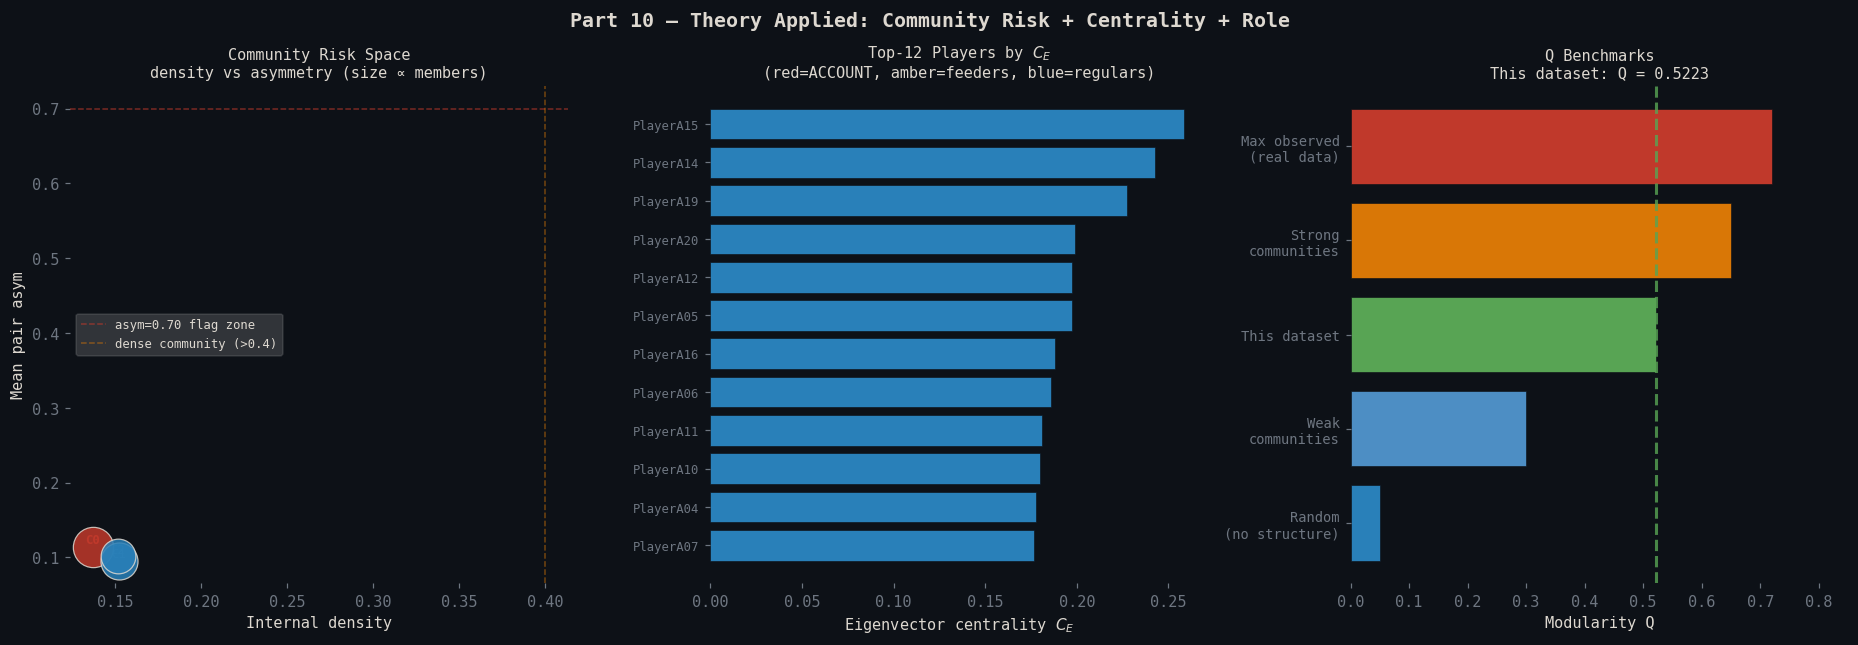


Notebook complete.
  Parts 1–8  →  mathematical framework (self-contained, no DB required)
  Part 9     →  architectural specification for the detection pipeline
  Part 10    →  validation: theory maps to detection signals on simulated data


In [16]:

# ── Part 10: Theory ↔ Detection Mapping — Simulated 80-Player Dataset ────────
# Uses G_lcc, df_edges, G_real built in Part 3.
# Applies community detection → computes per-community risk → visualises.

BG = "#0d1117"; WHITE = "#ddd8d0"; DIM = "#6e7681"
CRED = "#c0392b"; CBLUE = "#2980b9"; CAMBER = "#d97706"; CGRAY = "#555566"

# ─── Re-run community detection on the LCC (in case kernel is fresh) ─────────
communities_lcc = list(nx_comm.louvain_communities(G_lcc.to_undirected(), seed=42))
Q_lcc = nx_comm.modularity(G_lcc.to_undirected(), communities_lcc)
node_to_comm = {}
for c_idx, comm in enumerate(communities_lcc):
    for node in comm:
        node_to_comm[node] = c_idx

# ─── Per-community risk summary ───────────────────────────────────────────────
comm_rows = []
for c_idx, comm in enumerate(communities_lcc):
    sub_nodes = set(comm)
    # edges internal to this community
    int_edges = [(u, v) for u, v in G_lcc.edges() if u in sub_nodes and v in sub_nodes]
    n = len(sub_nodes)
    max_edges = n * (n - 1)  # directed
    density   = len(int_edges) / max_edges if max_edges > 0 else 0.0
    # volume + asym for internal edges
    sub_df = df_edges[
        df_edges["donor"].isin(sub_nodes) & df_edges["recipient"].isin(sub_nodes)
    ]
    vol   = sub_df["total_transfer_bb"].sum()
    mean_asym = sub_df["asym"].mean() if len(sub_df) else 0.0
    # has ACCOUNT?
    has_account = "bustNUTSonU" in sub_nodes
    comm_rows.append(dict(
        comm_id=c_idx, members=n, density=density,
        internal_vol=vol, mean_asym=mean_asym,
        has_account=has_account,
        risk_score=0.4*mean_asym + 0.3*(density/0.5) + 0.3*(vol/2000)
    ))
df_comm_sim = pd.DataFrame(comm_rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
df_comm_sim["risk_rank"] = range(1, len(df_comm_sim)+1)

# ─── Centrality on the LCC ────────────────────────────────────────────────────
G_lcc_uw = G_lcc.to_undirected()
deg_c_lcc = nx.degree_centrality(G_lcc_uw)
try:
    eig_c_lcc = nx.eigenvector_centrality(G_lcc_uw, max_iter=500)
except nx.PowerIterationFailedConvergence:
    eig_c_lcc = {n: 0.0 for n in G_lcc_uw.nodes}
bet_c_lcc = nx.betweenness_centrality(G_lcc_uw, normalized=True)

# ─── Print theory ↔ detection summary ─────────────────────────────────────────
print("="*64)
print("  THEORY ↔ DETECTION MAPPING  (simulated 80-player dataset)")
print("="*64)
print(f"  Part 1  G=(V,E,w)    |V|={G_lcc.number_of_nodes()} nodes,  |E|={G_lcc.number_of_edges()} directed edges")
print(f"  Part 2  asym per pair  max asym = {df_edges['asym'].max():.3f}  "
      f"({df_edges['asym'].max():.0%} → feeder dump edge)")
print(f"  Part 3  strength       top net recipient: "
      f"{max(in_strength, key=lambda n: in_strength[n]-out_strength.get(n,0))}")
print(f"  Part 6  modularity Q   = {Q_lcc:.4f}")
print(f"  Part 7  subgraph dens  riskiest community: "
      f"C{df_comm_sim.iloc[0]['comm_id']}  density={df_comm_sim.iloc[0]['density']:.3f}")
top_eig = max(eig_c_lcc, key=eig_c_lcc.get)
print(f"  Part 8  eigen C_E      top hub: {top_eig}  (C_E={eig_c_lcc[top_eig]:.3f})")
print()
print("  Community risk ranking:")
for _, row in df_comm_sim.iterrows():
    flag = " ← CRITICAL (ring)" if row["has_account"] else ""
    print(f"    #{int(row.risk_rank):2d}  C{int(row.comm_id)}  "
          f"members={int(row.members):3d}  density={row.density:.3f}  "
          f"asym={row.mean_asym:.3f}  vol={row.internal_vol:.0f}bb{flag}")

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor=BG)
fig.suptitle("Part 10 — Theory Applied: Community Risk + Centrality + Role",
             fontsize=13, fontweight="bold", color=WHITE, y=0.97)

# ── Panel 1: community density vs mean asym scatter ───────────────────────────
ax0 = axes[0]; ax0.set_facecolor(BG)
for sp in ax0.spines.values(): sp.set_visible(False)

for _, row in df_comm_sim.iterrows():
    col  = CRED if row["has_account"] else CBLUE
    sz   = 120 + row["members"] * 18
    ax0.scatter(row["density"], row["mean_asym"], s=sz, color=col,
                alpha=0.85, edgecolors=WHITE, linewidths=0.8, zorder=4)
    ax0.annotate(f"C{int(row.comm_id)}", (row["density"], row["mean_asym"]),
                 fontsize=8, color=col if row["has_account"] else DIM,
                 ha="center", va="bottom", fontweight="bold" if row["has_account"] else "normal")

ax0.axhline(0.7, color=CRED, lw=1, ls="--", alpha=0.6, label="asym=0.70 flag zone")
ax0.axvline(0.4, color=CAMBER, lw=1, ls="--", alpha=0.5, label="dense community (>0.4)")
ax0.set_xlabel("Internal density", color=WHITE); ax0.set_ylabel("Mean pair asym", color=WHITE)
ax0.set_title("Community Risk Space\ndensity vs asymmetry (size ∝ members)", color=WHITE, fontsize=10)
ax0.tick_params(colors=DIM); ax0.legend(fontsize=8, framealpha=0.15, labelcolor=WHITE)

# ── Panel 2: eigenvector centrality bar — top 12 ──────────────────────────────
ax1 = axes[1]; ax1.set_facecolor(BG)
for sp in ax1.spines.values(): sp.set_visible(False)

top12 = sorted(eig_c_lcc.items(), key=lambda x: -x[1])[:12]
names  = [x[0] for x in top12]
values = [x[1] for x in top12]
bar_cols = [CRED if n=="bustNUTSonU" else CAMBER if n in FEEDERS else CBLUE for n in names]
ax1.barh(range(len(names)), values, color=bar_cols, edgecolor=BG, linewidth=0.4)
ax1.set_yticks(range(len(names)))
ax1.set_yticklabels(names, fontsize=8, color=WHITE, fontfamily="monospace")
ax1.set_xlabel("Eigenvector centrality $C_E$", color=WHITE)
ax1.set_title("Top-12 Players by $C_E$\n(red=ACCOUNT, amber=feeders, blue=regulars)",
              color=WHITE, fontsize=10)
ax1.tick_params(colors=DIM)
ax1.invert_yaxis()

# ── Panel 3: Q bar chart with reference lines ──────────────────────────────────
ax2 = axes[2]; ax2.set_facecolor(BG)
for sp in ax2.spines.values(): sp.set_visible(False)

ref_Q   = [("Random\n(no structure)", 0.05, CBLUE),
           ("Weak\ncommunities",       0.30, "#4d8ec4"),
           ("This dataset",            Q_lcc, "#58a454"),
           ("Strong\ncommunities",     0.65, CAMBER),
           ("Max observed\n(real data)", 0.72, CRED)]
y_pos   = range(len(ref_Q))
ax2.barh(list(y_pos), [r[1] for r in ref_Q],
         color=[r[2] for r in ref_Q], edgecolor=BG, linewidth=0.4)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels([r[0] for r in ref_Q], fontsize=9, color=WHITE)
ax2.set_xlabel("Modularity Q", color=WHITE)
ax2.set_title(f"Q Benchmarks\nThis dataset: Q = {Q_lcc:.4f}", color=WHITE, fontsize=10)
ax2.axvline(Q_lcc, color="#58a454", lw=2, ls="--", alpha=0.8)
ax2.set_xlim(0, 0.85)
ax2.tick_params(colors=DIM)

plt.tight_layout()
plt.show()

print()
print("Notebook complete.")
print(f"  Parts 1–8  →  mathematical framework (self-contained, no DB required)")
print(f"  Part 9     →  architectural specification for the detection pipeline")
print(f"  Part 10    →  validation: theory maps to detection signals on simulated data")
